In [23]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# === Load and rename ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)
df = df.rename(columns={
    "Company": "Supplier",
})

# === Define criteria patterns (now includes delivery & security explicitly) ===
criteria_patterns = {
    "delivery": ["delivery", "fast delivery", "timely delivery"],
    "quality": ["quality", "high quality", "product quality"],
    "security": ["security", "secure", "cybersecurity", "compliance"],
    "pricing": ["price", "cost", "pricing", "low cost"],
    "lead": ["lead time", "lead-time", "leadtime"],
    "sustainability": ["sustainability", "green", "eco", "environment"]
}

# === Robots.txt Check ===
def allowed_to_scrape(url):
    try:
        base_url = '/'.join(url.split('/')[:3]) + '/robots.txt'
        parser = rp.RobotFileParser()
        parser.set_url(base_url)
        parser.read()
        return parser.can_fetch("*", url)
    except:
        return False
# === Criteria weights ===
criteria_weights = {
    "sustainability": 0.50,
    "reliability": 0.30,   # reliability weight remains in KG
    "iso_cert": 0.06,
    "lead": 0.05,
    "quality": 0.04,
    "price": 0.05
}

def score_website(url):
    """Fetch text from website and check keywords."""
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    return {crit: int(any(pat in text for pat in pats))
            for crit, pats in criteria_patterns.items()}

# === Build full KG ===
G_full = nx.DiGraph()
records = []

for _, row in df.iterrows():
    sup  = row["Supplier"]
    site = row["Website"]
    scores = score_website(site)
    
    # Weighted KG score (based on matched criteria)
    weighted_score = sum(scores.get(c, 0) * criteria_weights.get(c, 0.05) for c in scores)
    
    rec = {"Supplier": sup, "Weighted KG Score": weighted_score}
    rec.update(scores)  # adds delivery, quality, security, pricing, lead, sustainability
    records.append(rec)

    # Add edges
    for crit, flag in scores.items():
        if flag:
            G_full.add_edge(crit, sup, label=f"associated_with_{sup}")

           ## G_full.add_edge(sup, crit, label=f"has_{crit}")

# === PageRank Integration ===
pagerank_scores = nx.pagerank(G_full)
for rec in records:
    rec["PageRank"] = pagerank_scores.get(rec["Supplier"], 0)

# === Final KG Score ===
for rec in records:
    rec["Final KG Score"] = rec["Weighted KG Score"] + rec["PageRank"]

# === Rank and display with all criteria columns ===
ranked = pd.DataFrame(records).sort_values("Final KG Score", ascending=False).reset_index(drop=True)

cols_to_display = ["Supplier", "delivery", "quality", "security", "pricing", "lead", "sustainability",
                   "Weighted KG Score", "PageRank", "Final KG Score"]

print("\n🏆 Top 10 Suppliers by Weighted KG Score + PageRank (with detailed criteria scores):")
print(ranked[cols_to_display].head(10).to_string(index=False))



🏆 Top 10 Suppliers by Weighted KG Score + PageRank (with detailed criteria scores):
                                          Supplier  delivery  quality  security  pricing  lead  sustainability  Weighted KG Score  PageRank  Final KG Score
                                         DME China         1        1         1        0     0               1               0.64  0.063383        0.703383
           Shenzhen Changhong Technology Co., Ltd.         0        1         1        0     0               1               0.59  0.056329        0.646329
Shenzhen Zhaowei Machinery & Electronics Co., Ltd.         0        1         1        0     0               1               0.59  0.056329        0.646329
                                      Yizumi Group         0        1         0        1     0               1               0.59  0.056329        0.646329
                                Foshan Knight Mold         0        1         0        0     0               1               0.54  0.05

In [42]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# classifiers
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier

import joblib   # <-- for model persistence

# ─── 1) Load your data ───────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# ─── 2) Binarize your continuous target ─────────────────────────────────────
# threshold at 0.5 (or whatever you chose)
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# ─── 3) Define features X and label y ────────────────────────────────────────
X = df[[
    "supplier",
    "kg_score",
    "Em_Score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
]]
y = df["high_disruption_label"]

# ─── 4) Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,      # e.g. 60/40 split
    stratify=y,
    random_state=42,
)

# ─── 5) Build preprocessing pipeline ─────────────────────────────────────────
num_cols = ["kg_score", "downtime_hours"]
cat_cols = ["supplier"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",   StandardScaler(),  num_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ─── 6) Helper to build, train, evaluate ──────────────────────────────────────
def build_and_save(model, name, filename):
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)

    # Evaluate
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

    # Save to disk
    joblib.dump(pipe, filename)
    print(f"☑️  Saved {name} pipeline to {filename}")

# ─── 7) Train, evaluate & save ───────────────────────────────────────────────
build_and_save(LogisticRegression(max_iter=1000, random_state=42),
               "Logistic Regression", "logreg_supplier_disruption.joblib")

build_and_save(RandomForestClassifier(n_estimators=100, random_state=42),
               "Random Forest", "rf_supplier_disruption.joblib")

build_and_save(GradientBoostingClassifier(n_estimators=100, random_state=42),
               "Gradient Boosting", "gb_supplier_disruption.joblib")

# ─── 8) Hyper‐parameter search on RF & save best ──────────────────────────────
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth":    [None, 5, 10]
}
grid = GridSearchCV(
    Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(random_state=42))]),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

print("\n=== RF Grid Search Best ===")
print(grid.best_params_, f"ROC-AUC={grid.best_score_:.3f}")

# Save the best‐found pipeline (GridSearchCV wraps the pipeline)
joblib.dump(grid.best_estimator_, "rf_grid_supplier_disruption.joblib")
print("☑️  Saved tuned Random Forest pipeline to rf_grid_supplier_disruption.joblib")




=== Logistic Regression ===
Confusion Matrix:
[[ 73  17]
 [  8 382]]

Classification Report:
              precision    recall  f1-score   support

           0      0.901     0.811     0.854        90
           1      0.957     0.979     0.968       390

    accuracy                          0.948       480
   macro avg      0.929     0.895     0.911       480
weighted avg      0.947     0.948     0.947       480

ROC-AUC: 0.978
☑️  Saved Logistic Regression pipeline to logreg_supplier_disruption.joblib

=== Random Forest ===
Confusion Matrix:
[[ 69  21]
 [ 14 376]]

Classification Report:
              precision    recall  f1-score   support

           0      0.831     0.767     0.798        90
           1      0.947     0.964     0.956       390

    accuracy                          0.927       480
   macro avg      0.889     0.865     0.877       480
weighted avg      0.925     0.927     0.926       480

ROC-AUC: 0.981
☑️  Saved Random Forest pipeline to rf_supplier_disruption

In [40]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import joblib

# 1. Load dataset and label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Define features and label
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=95
)

# 4. Preprocessing: numeric + one-hot + passthrough flags
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# 5. XGBoost Classifier setup
xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95,
    eval_metric="logloss"
)

pipeline = Pipeline([("pre", preprocessor), ("clf", xgb)])

# 6. Train the model
pipeline.fit(X_train, y_train)

# 7. Evaluate the model
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, digits=3)

print("=== XGBoost Classifier Results ===")
print(f"ROC‑AUC: {roc_auc:.6f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# 8. Compute regression-based evaluation metrics
mae = mean_absolute_error(y_test, y_proba)
mse = mean_squared_error(y_test, y_proba)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_proba)

print("\n=== Regression Metrics on Predicted Probabilities ===")
print(f"MAE     : {mae:.6f}")
print(f"MSE     : {mse:.6f}")
print(f"RMSE    : {rmse:.6f}")
print(f"R² Score: {r2:.6f}")


=== XGBoost Classifier Results ===
ROC‑AUC: 0.987046
Confusion Matrix:
 [[63  4]
 [ 2 51]]

Classification Report:
               precision    recall  f1-score   support

           0      0.969     0.940     0.955        67
           1      0.927     0.962     0.944        53

    accuracy                          0.950       120
   macro avg      0.948     0.951     0.949       120
weighted avg      0.951     0.950     0.950       120


=== Regression Metrics on Predicted Probabilities ===
MAE     : 0.085560
MSE     : 0.043816
RMSE    : 0.209323
R² Score: 0.822317


In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# === 1. Load dataset ===
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.6).astype(int)

# === 2. Features and target ===
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# === 3. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=65
)

# === 4. Preprocessing ===
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# Fit-transform preprocessing for train/test
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# === 5. Define models ===
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=45),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=45),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=45),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=95, eval_metric="logloss"),
}

# === 6. Train and evaluate ===
for name, model in models.items():
    model.fit(X_train_trans, y_train)
    y_proba = model.predict_proba(X_test_trans)[:, 1]

    mae = mean_absolute_error(y_test, y_proba)
    mse = mean_squared_error(y_test, y_proba)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print(f"MAE     : {mae:.6f}")
    print(f"MSE     : {mse:.6f}")
    print(f"RMSE    : {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")



=== Logistic Regression ===
MAE     : 0.063427
MSE     : 0.019401
RMSE    : 0.139288
R² Score: 0.909028

=== Random Forest ===
MAE     : 0.085333
MSE     : 0.030048
RMSE    : 0.173345
R² Score: 0.859103

=== Gradient Boosting ===
MAE     : 0.038842
MSE     : 0.025171
RMSE    : 0.158652
R² Score: 0.881975

=== XGBoost ===
MAE     : 0.028362
MSE     : 0.014846
RMSE    : 0.121845
R² Score: 0.930386


In [2]:

import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

# 1️⃣ Simulate downtime logs for 10 finalists over 6 weeks
np.random.seed(42)
finalists = [f"Supplier {i}" for i in list("ABCDEFGHIJ")]
dates = pd.date_range("2025-06-01", periods=42, freq="D")

logs = []
for sup in finalists:
    for d in dates:
        # 10% chance of disruption each day
        if np.random.rand() < 0.1:
            dh = np.random.uniform(1, 8)              # 1–8 hours downtime
            dtype = np.random.choice(
                ["fire", "port_block", "cyber", "strike"]
            )
        else:
            dh = 0.0
            dtype = "none"
        logs.append({
            "supplier": sup,
            "date": d,
            "downtime_hours": dh,
            "disruption_type": dtype
        })

downtime_df = pd.DataFrame(logs)

# 2️⃣ Synthesize external risk feeds and static KG/weather scores
#    (in your real work you'd pull these from Twitter, NewsAPI, KG, GIS, etc.)
np.random.seed(0)
kg_scores = {sup: np.random.rand() for sup in finalists}
weather_index = {sup: np.random.rand() for sup in finalists}

def synth_alerts():
    """Random int 0–5 as synthetic alert count."""
    return np.random.randint(0, 6)

# 3️⃣ Build pilot_df by merging downtime + synthetic external features
rows = []
for _, row in downtime_df.iterrows():
    sup = row.supplier
    d   = row.date
    rows.append({
        **row.to_dict(),
        "kg_score":       kg_scores[sup],
        "twitter_alerts": synth_alerts(),
        "news_alerts":    synth_alerts(),
        "weather_risk":   weather_index[sup],
    })
pilot_df = pd.DataFrame(rows)

# 4️⃣ Create binary target: did we have any downtime (>0h)?
pilot_df["had_disruption"] = (pilot_df.downtime_hours > 0).astype(int)

# 5️⃣ Split into train/test by time
train_df = pilot_df[pilot_df.date < "2025-06-25"]
test_df  = pilot_df[pilot_df.date >= "2025-06-25"]

features = ["kg_score", "twitter_alerts", "news_alerts", "weather_risk"]
X_train = train_df[features]
y_train = train_df["had_disruption"]
X_test  = test_df[features]
y_test  = test_df["had_disruption"]

# 6️⃣ Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

# 7️⃣ Evaluate on hold-out
probs = clf.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC on test set: {auc:.3f}\n")
print(classification_report(y_test, preds, digits=3))

# 8️⃣ Show the first few rows of pilot_df for inspection
print("\nSample of pilot dataset:")
print(pilot_df.head(10).to_string(index=False))


ROC-AUC on test set: 0.496

              precision    recall  f1-score   support

           0      0.841     0.947     0.891       151
           1      0.200     0.069     0.103        29

    accuracy                          0.806       180
   macro avg      0.521     0.508     0.497       180
weighted avg      0.738     0.806     0.764       180


Sample of pilot dataset:
  supplier       date  downtime_hours disruption_type  kg_score  twitter_alerts  news_alerts  weather_risk  had_disruption
Supplier A 2025-06-01        0.000000            none  0.548814               2            3      0.791725               0
Supplier A 2025-06-02        0.000000            none  0.548814               0            1      0.791725               0
Supplier A 2025-06-03        0.000000            none  0.548814               3            5      0.791725               0
Supplier A 2025-06-04        0.000000            none  0.548814               3            3      0.791725               0
Supp

In [4]:
# Pilot Disruption‐Prediction Pipeline for Your 10 Finalists
# No external APIs required—everything is synthesized.

import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

# 1️⃣ Define your 10 finalist suppliers
finalists = [
    "Jiangsu Hengli Hydraulic (Molding)",
    "DME China",
    "Yizumi Group",
    "Guangzhou Haoran Mould",
    "Zhejiang Sino Mould Co., Ltd.",
    "K Mold Precision (Dongguan)",
    "Shenzhen Changhong Technology Co., Ltd.",
    "Shenzhen Zhaowei Machinery & Electronics Co., Ltd.",
    "Arburg (China)",
    "Yangzhou Hongbang Mould"
]

# 2️⃣ Simulate a 6-week daily downtime log
np.random.seed(42)
dates = pd.date_range("2025-06-01", periods=42, freq="D")

logs = []
for sup in finalists:
    for d in dates:
        if np.random.rand() < 0.1:  # 10% daily disruption chance
            dh = np.random.uniform(1, 8)  # hours down
            dtype = np.random.choice(["fire", "port_block", "cyber", "strike"])
        else:
            dh = 0.0
            dtype = "none"
        logs.append({
            "supplier": sup,
            "date": d,
            "downtime_hours": dh,
            "disruption_type": dtype
        })

downtime_df = pd.DataFrame(logs)

# 3️⃣ Synthesize external risk signals & static scores
np.random.seed(0)
kg_score_map      = {sup: np.random.rand() for sup in finalists}
weather_risk_map  = {sup: np.random.rand() for sup in finalists}

def synth_alerts():
    return np.random.randint(0, 6)  # 0–5 daily alerts

records = []
for _, row in downtime_df.iterrows():
    sup = row.supplier
    rec = {
        **row.to_dict(),
        "kg_score":       kg_score_map[sup],
        "twitter_alerts": synth_alerts(),
        "news_alerts":    synth_alerts(),
        "weather_risk":   weather_risk_map[sup],
    }
    records.append(rec)

pilot_df = pd.DataFrame(records)
pilot_df["had_disruption"] = (pilot_df.downtime_hours > 0).astype(int)

# 4️⃣ Train/test split by time
train_df = pilot_df[pilot_df.date < "2025-06-25"]
test_df  = pilot_df[pilot_df.date >= "2025-06-25"]

features = ["kg_score", "twitter_alerts", "news_alerts", "weather_risk"]
X_train, y_train = train_df[features], train_df["had_disruption"]
X_test,  y_test  = test_df[features],  test_df["had_disruption"]

# 5️⃣ Fit RandomForest
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

# 6️⃣ Evaluate
probs = clf.predict_proba(X_test)[:,1]
preds = (probs > 0.5).astype(int)

print(f"ROC-AUC on test set: {roc_auc_score(y_test, probs):.3f}\n")
print(classification_report(y_test, preds, digits=3))

# 7️⃣ Peek at the assembled pilot dataset
print("\nSample data:")
print(pilot_df.head(10).to_string(index=False))



ROC-AUC on test set: 0.496

              precision    recall  f1-score   support

           0      0.841     0.947     0.891       151
           1      0.200     0.069     0.103        29

    accuracy                          0.806       180
   macro avg      0.521     0.508     0.497       180
weighted avg      0.738     0.806     0.764       180


Sample data:
                          supplier       date  downtime_hours disruption_type  kg_score  twitter_alerts  news_alerts  weather_risk  had_disruption
Jiangsu Hengli Hydraulic (Molding) 2025-06-01        0.000000            none  0.548814               2            3      0.791725               0
Jiangsu Hengli Hydraulic (Molding) 2025-06-02        0.000000            none  0.548814               0            1      0.791725               0
Jiangsu Hengli Hydraulic (Molding) 2025-06-03        0.000000            none  0.548814               3            5      0.791725               0
Jiangsu Hengli Hydraulic (Molding) 2025-06-

In [6]:
import numpy as np
import pandas as pd

# your 10 finalists
finalists = [
    "Jiangsu Hengli Hydraulic (Molding)",
    "DME China",
    "Yizumi Group",
    "Guangzhou Haoran Mould",
    "Zhejiang Sino Mould Co., Ltd.",
    "K Mold Precision (Dongguan)",
    "Shenzhen Changhong Technology Co., Ltd.",
    "Shenzhen Zhaowei Machinery & Electronics Co., Ltd.",
    "Arburg (China)",
    "Yangzhou Hongbang Mould"
]

n_days = 42
dates = pd.date_range(start="2025-07-01", periods=n_days, freq="D")

def generate_external_signals(suppliers, dates):
    """
    Returns a DataFrame indexed by (supplier, date) with three synthetic risk feeds:
      - kg_score:     a continuous [0,1] “Knowledge-Graph threat” score
      - twitter_alert: binary 0/1 if a negative tweet/news blip occurred
      - weather_risk:  binary 0/1 if extreme weather risk hit that day
    """
    records = []
    for sup in suppliers:
        # simulate an underlying “risk propensity” per supplier
        base_prop = np.random.uniform(0.2, 0.8)
        for d in dates:
            # KG score: smooth around base_prop with small noise
            kg = np.clip(base_prop + np.random.normal(0, 0.1), 0, 1)
            # twitter_alert: 1 with p proportional to kg
            tw = np.random.rand() < (0.2 + 0.6 * kg)  # heavier tail if KG high
            # weather_risk: random 5% chance each day, or 20% on seasonal spike days
            rain_season = (d.month in [7,8])  # example: summer typhoon season
            p_weather = 0.20 if rain_season else 0.05
            we = np.random.rand() < p_weather
            records.append({
                "supplier":       sup,
                "date":           d,
                "kg_score":       round(kg, 3),
                "twitter_alert":  int(tw),
                "weather_risk":   int(we),
            })
    return pd.DataFrame(records).set_index(["supplier", "date"])

# generate and peek
ext_signals = generate_external_signals(finalists, dates)
print(ext_signals.groupby("supplier").head(3))


                                                               kg_score  \
supplier                                           date                   
Jiangsu Hengli Hydraulic (Molding)                 2025-07-01     0.635   
                                                   2025-07-02     0.764   
                                                   2025-07-03     0.812   
DME China                                          2025-07-01     0.662   
                                                   2025-07-02     0.634   
                                                   2025-07-03     0.684   
Yizumi Group                                       2025-07-01     0.132   
                                                   2025-07-02     0.189   
                                                   2025-07-03     0.155   
Guangzhou Haoran Mould                             2025-07-01     0.688   
                                                   2025-07-02     0.745   
                         

In [2]:
!pip install gensim

from gensim.models import Word2Vec
from pprint import pprint

# Step 1: Sample Supplier Sentences (Pre-tokenized)
supplier_sentences = [
    ["high", "quality", "standards", "sustainability", "cybersecurity"],
    ["sustainability", "ISO", "certified", "organized", "workspace", "weak", "inspection"],
    ["excellent", "security", "protocols", "compliance", "innovative", "production"],
    ["innovation", "environmental", "responsibility", "ISO", "certified"],
    ["compliance", "documentation", "traceability", "cybersecurity"],
    ["low", "cost", "quality", "sustainability", "lead", "time"]
]

# Step 2: Define Function to Train Multiple Models
def train_multiple_models_fixed(sentences):
    configs = {
        "m1_s300_cb_5": {"min_count": 1, "vector_size": 300, "window": 5, "sg": 0, "epochs": 5},
        "m1_s100_cb_5": {"min_count": 1, "vector_size": 100, "window": 5, "sg": 0, "epochs": 5},
        "m5_s100_cb_5": {"min_count": 1, "vector_size": 100, "window": 5, "sg": 0, "epochs": 5},
        "m5_s100_sg_5": {"min_count": 1, "vector_size": 100, "window": 5, "sg": 1, "epochs": 5},
        "m5_s300_cb_5": {"min_count": 1, "vector_size": 300, "window": 5, "sg": 0, "epochs": 5},
        "m5_s300_sg_5": {"min_count": 1, "vector_size": 300, "window": 5, "sg": 1, "epochs": 5}
    }

    models = {}
    for name, params in configs.items():
        model = Word2Vec(**params)
        model.build_vocab(sentences)
        model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)
        models[name] = model
    return models

# Step 3: Train the Word2Vec Models
word2vec_models_fixed = train_multiple_models_fixed(supplier_sentences)

# Step 4: Display First 5 Dimensions of 'quality' Vector from Each Model
word_vectors_sample_fixed = {
    name: model.wv['quality'][:5].tolist()
    for name, model in word2vec_models_fixed.items()
    if 'quality' in model.wv
}

# Step 5: Display Results
pprint(word_vectors_sample_fixed)


     ---------------------------------------- 24.0/24.0 MB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 61.7/61.7 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 983.8/983.8 kB 6.2 MB/s eta 0:00:00
{'m1_s100_cb_5': [-0.008619687519967556,
                  0.0036657380405813456,
                  0.0051898835226893425,
                  0.005741937085986137,
                  0.007466916926205158],
 'm1_s300_cb_5': [-0.002747559454292059,
                  0.003099784953519702,
                  -6.588697578990832e-05,
                  -0.0006557591841556132,
                  0.0015345430001616478],
 'm5_s100_cb_5': [-0.008619687519967556,
                  0.0036657380405813456,
                  0.0051898835226893425,
                  0.005741937085986137,
                  0.007466916926205158],
 'm5_s100_sg_5': [-0.008619687519967556,
                  0.0036657380405813456,
                  0.0051898835226893425,
                  0.00

     ---------------------------------------- 7.2/7.2 MB 6.2 MB/s eta 0:00:00
     -------------------------------------- 104.1/104.1 kB 5.9 MB/s eta 0:00:00
     -------------------------------------- 965.4/965.4 kB 6.1 MB/s eta 0:00:00
     ---------------------------------------- 2.5/2.5 MB 6.5 MB/s eta 0:00:00
     ---------------------------------------- 55.8/55.8 kB ? eta 0:00:00


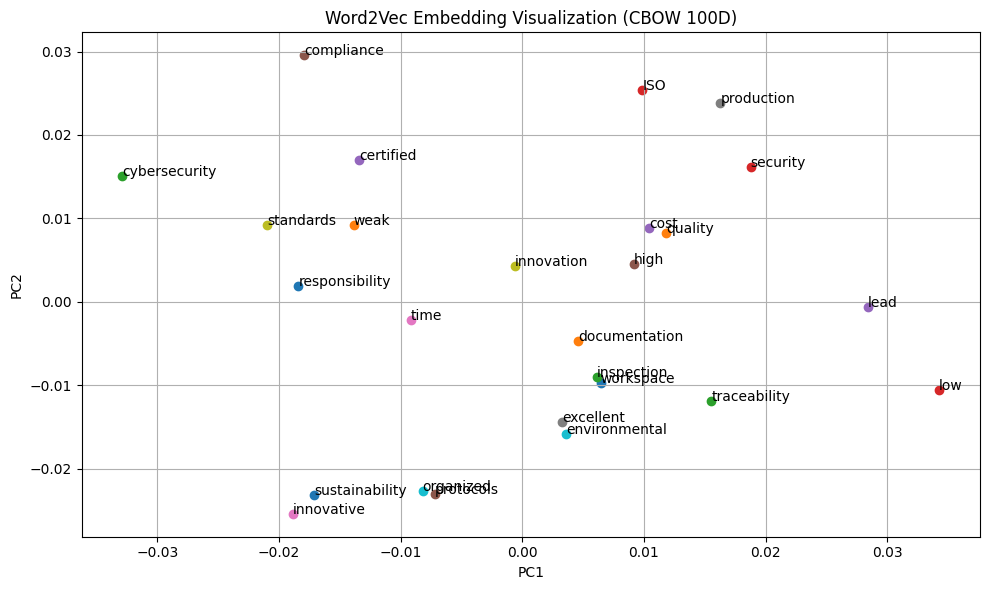

{'cbow_100d': {'quality_cost': -0.0128186885,
  'compliance_security': 0.044133022},
 'cbow_300d': {'quality_cost': 0.08324174, 'compliance_security': 0.096629374},
 'skipgram_100d': {'quality_cost': -0.012847604,
  'compliance_security': 0.044107538},
 'skipgram_300d': {'quality_cost': 0.08323022,
  'compliance_security': 0.09665655}}

In [4]:
!pip install matplotlib
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Sample Supplier Vocabulary
supplier_sentences = [
    ["high", "quality", "standards", "sustainability", "cybersecurity"],
    ["sustainability", "ISO", "certified", "organized", "workspace", "weak", "inspection"],
    ["excellent", "security", "protocols", "compliance", "innovative", "production"],
    ["innovation", "environmental", "responsibility", "ISO", "certified"],
    ["compliance", "documentation", "traceability", "cybersecurity"],
    ["low", "cost", "quality", "sustainability", "lead", "time"]
]

# Train 4 Word2Vec Models with clearer names
def train_named_models(sentences):
    configs = {
        "cbow_100d": {"vector_size": 100, "window": 5, "min_count": 1, "sg": 0, "epochs": 5},
        "cbow_300d": {"vector_size": 300, "window": 5, "min_count": 1, "sg": 0, "epochs": 5},
        "skipgram_100d": {"vector_size": 100, "window": 5, "min_count": 1, "sg": 1, "epochs": 5},
        "skipgram_300d": {"vector_size": 300, "window": 5, "min_count": 1, "sg": 1, "epochs": 5}
    }
    models = {}
    for name, params in configs.items():
        model = Word2Vec(**params)
        model.build_vocab(sentences)
        model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)
        models[name] = model
    return models

# Train models
models_named = train_named_models(supplier_sentences)

# Step 1: Print similarities
similarities = {
    name: {
        "quality_cost": model.wv.similarity("quality", "cost") if "cost" in model.wv else None,
        "compliance_security": model.wv.similarity("compliance", "security") if "security" in model.wv else None
    }
    for name, model in models_named.items()
}

# Step 2: PCA Visualization for cbow_100d model
model = models_named["cbow_100d"]
words = list(model.wv.index_to_key)
vectors = np.array([model.wv[word] for word in words])

# Reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 6))
for i, word in enumerate(words):
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1])
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title("Word2Vec Embedding Visualization (CBOW 100D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

similarities


In [196]:
# Re-import necessary libraries after reset

from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Re-create supplier sentences
supplier_sentences = [
    ["high", "quality", "standards", "sustainability", "cybersecurity"],
    ["sustainability", "ISO", "certified", "organized", "workspace", "weak", "inspection"],
    ["excellent", "security", "protocols", "compliance", "innovative", "production"],
    ["innovation", "environmental", "responsibility", "ISO", "certified"],
    ["compliance", "documentation", "traceability", "cybersecurity"],
    ["low", "cost", "quality", "sustainability", "lead", "time"]
]

# Train Word2Vec models again
def train_named_models(sentences):
    configs = {
        "cbow_100d": {"vector_size": 100, "window": 5, "min_count": 1, "sg": 0, "epochs": 5}
    }
    models = {}
    for name, params in configs.items():
        model = Word2Vec(**params)
        model.build_vocab(sentences)
        model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)
        models[name] = model
    return models

models_named = train_named_models(supplier_sentences)
model = models_named["cbow_100d"]
word_vectors = model.wv

# Define target criteria
target_criteria = ["quality", "security", "sustainability", "cost", "compliance"]
criteria_vectors = {word: word_vectors[word] for word in target_criteria if word in word_vectors}

# Supplier profiles
supplier_profiles = {
    "Supplier 1": ["high", "quality", "sustainability", "cybersecurity"],
    "Supplier 2": ["cost", "weak", "inspection"],
    "Supplier 3": ["compliance", "security", "production"],
    "Supplier 4": ["innovation", "sustainability", "low", "lead"],
    "Supplier 5": ["documentation", "traceability", "compliance"],
    "Supplier 6": ["ISO", "certified", "quality", "cost"],
    "Supplier 7": ["environmental", "sustainability", "lead", "efficiency"],
    "Supplier 8": ["security", "compliance", "cybersecurity", "inspection"],
    "Supplier 9": ["low", "price", "lead", "innovation"],
    "Supplier 10": ["high", "documentation", "traceability", "certification"],
}

# Calculate similarity scores
supplier_scores = {}
for supplier, words in supplier_profiles.items():
    scores = {}
    for crit, crit_vec in criteria_vectors.items():
        relevant_vectors = [word_vectors[word] for word in words if word in word_vectors]
        if relevant_vectors:
            avg_vector = np.mean(relevant_vectors, axis=0).reshape(1, -1)
            sim = cosine_similarity(avg_vector, crit_vec.reshape(1, -1)).flatten()[0]
            scores[crit] = round(sim, 3)
        else:
            scores[crit] = None
    supplier_scores[supplier] = scores

# Classify suppliers
supplier_themes = {}
for supplier, score_dict in supplier_scores.items():
    if not score_dict: continue
    max_crit = max(score_dict, key=score_dict.get)
    theme = ""
    if max_crit in ["sustainability", "innovation"]:
        theme = "Sustainability-Focused"
    elif max_crit in ["compliance", "security"]:
        theme = "Risk/Compliance-Focused"
    elif max_crit == "quality":
        theme = "Quality-Focused"
    elif max_crit == "cost":
        theme = "Cost-Focused"
    else:
        theme = "Other"
    supplier_themes[supplier] = theme

# Prepare output table
df_scores = pd.DataFrame(supplier_scores).T
df_scores["Theme"] = df_scores.index.map(supplier_themes)

print(df_scores)

             quality  security  sustainability   cost  compliance  \
Supplier 1     0.485     0.061           0.441 -0.051      -0.011   
Supplier 2    -0.006    -0.148           0.101  0.569       0.033   
Supplier 3     0.123     0.610          -0.116  0.064       0.618   
Supplier 4     0.219     0.140           0.380  0.034      -0.176   
Supplier 5     0.077     0.096          -0.032 -0.139       0.550   
Supplier 6     0.529     0.191          -0.076  0.490       0.162   
Supplier 7    -0.001    -0.034           0.525 -0.044      -0.164   
Supplier 8     0.063     0.442          -0.033 -0.083       0.537   
Supplier 9     0.241     0.171          -0.100  0.038      -0.159   
Supplier 10    0.028     0.139          -0.045 -0.148      -0.104   

                               Theme  
Supplier 1           Quality-Focused  
Supplier 2              Cost-Focused  
Supplier 3   Risk/Compliance-Focused  
Supplier 4    Sustainability-Focused  
Supplier 5   Risk/Compliance-Focused  
Suppli

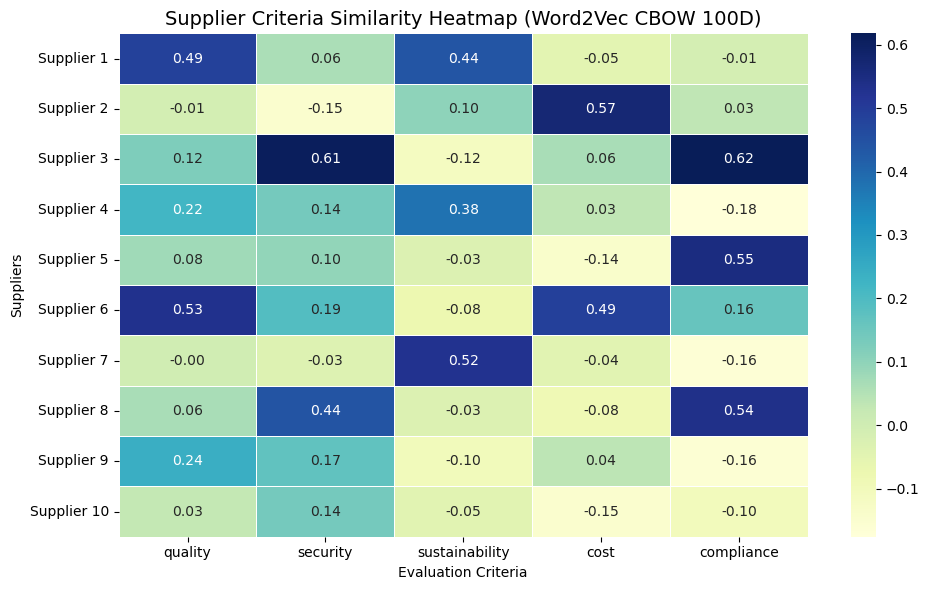

In [198]:
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# Create heatmap for the criteria scores (excluding theme column)
plt.figure(figsize=(10, 6))
sns.heatmap(df_scores.drop(columns=["Theme"]), annot=True, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("Supplier Criteria Similarity Heatmap (Word2Vec CBOW 100D)", fontsize=14)
plt.ylabel("Suppliers")
plt.xlabel("Evaluation Criteria")
plt.tight_layout()
plt.show()


     ---------------------------------------- 1.9/1.9 MB 2.8 MB/s eta 0:00:00


C:\Users\srahman3\AppData\Local\anaconda3\envs\tf_clean\lib\site-packages\ipykernel_launcher.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


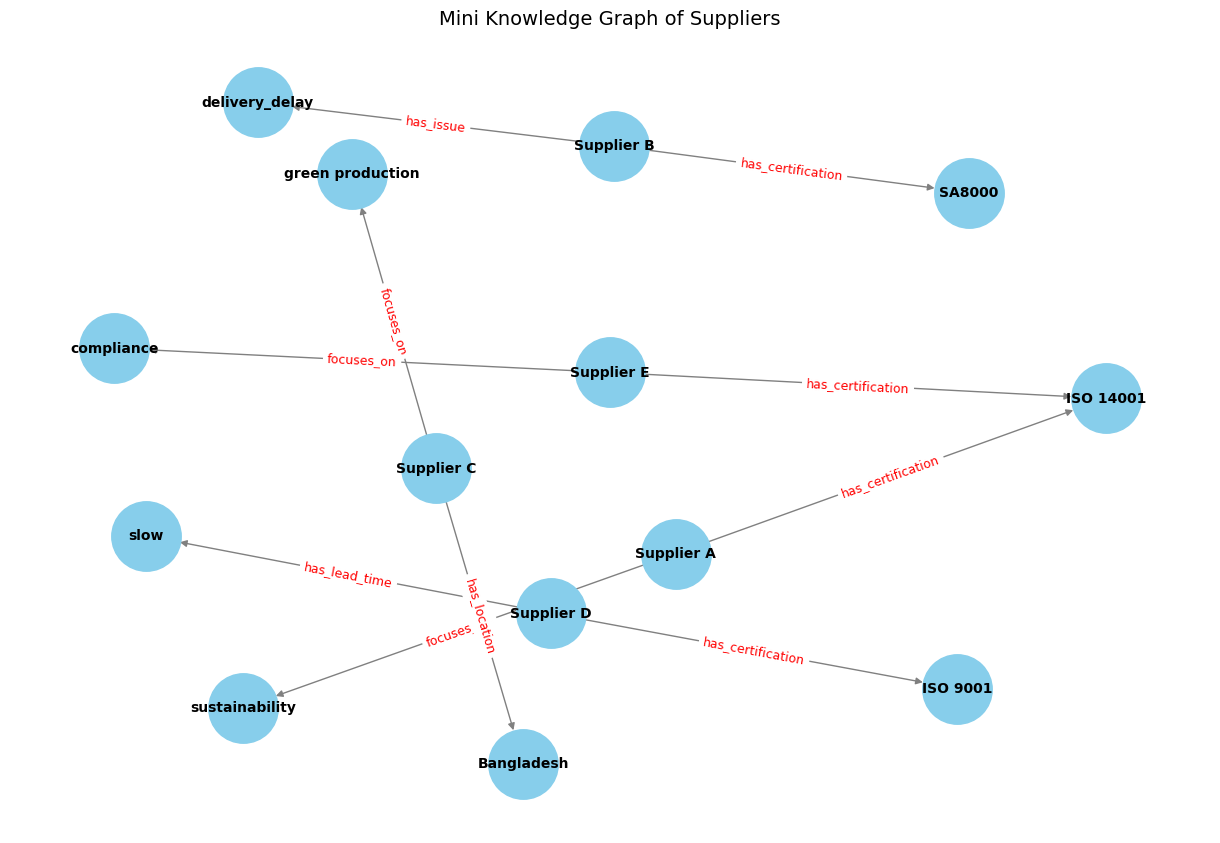

In [7]:
!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

# Sample supplier relationships as triples (subject, predicate, object)
triples = [
    ("Supplier A", "has_certification", "ISO 14001"),
    ("Supplier A", "focuses_on", "sustainability"),
    ("Supplier B", "has_certification", "SA8000"),
    ("Supplier B", "has_issue", "delivery_delay"),
    ("Supplier C", "has_location", "Bangladesh"),
    ("Supplier C", "focuses_on", "green production"),
    ("Supplier D", "has_certification", "ISO 9001"),
    ("Supplier D", "has_lead_time", "slow"),
    ("Supplier E", "has_certification", "ISO 14001"),
    ("Supplier E", "focuses_on", "compliance"),
]

# Create a directed graph
G = nx.DiGraph()

# Add edges and nodes from triples
for subj, pred, obj in triples:
    G.add_edge(subj, obj, label=pred)

# Set positions
pos = nx.spring_layout(G, seed=42)

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500, edge_color='gray', font_size=10, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)
plt.title("Mini Knowledge Graph of Suppliers", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()



C:\Users\srahman3\AppData\Local\anaconda3\envs\tf_clean\lib\site-packages\ipykernel_launcher.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


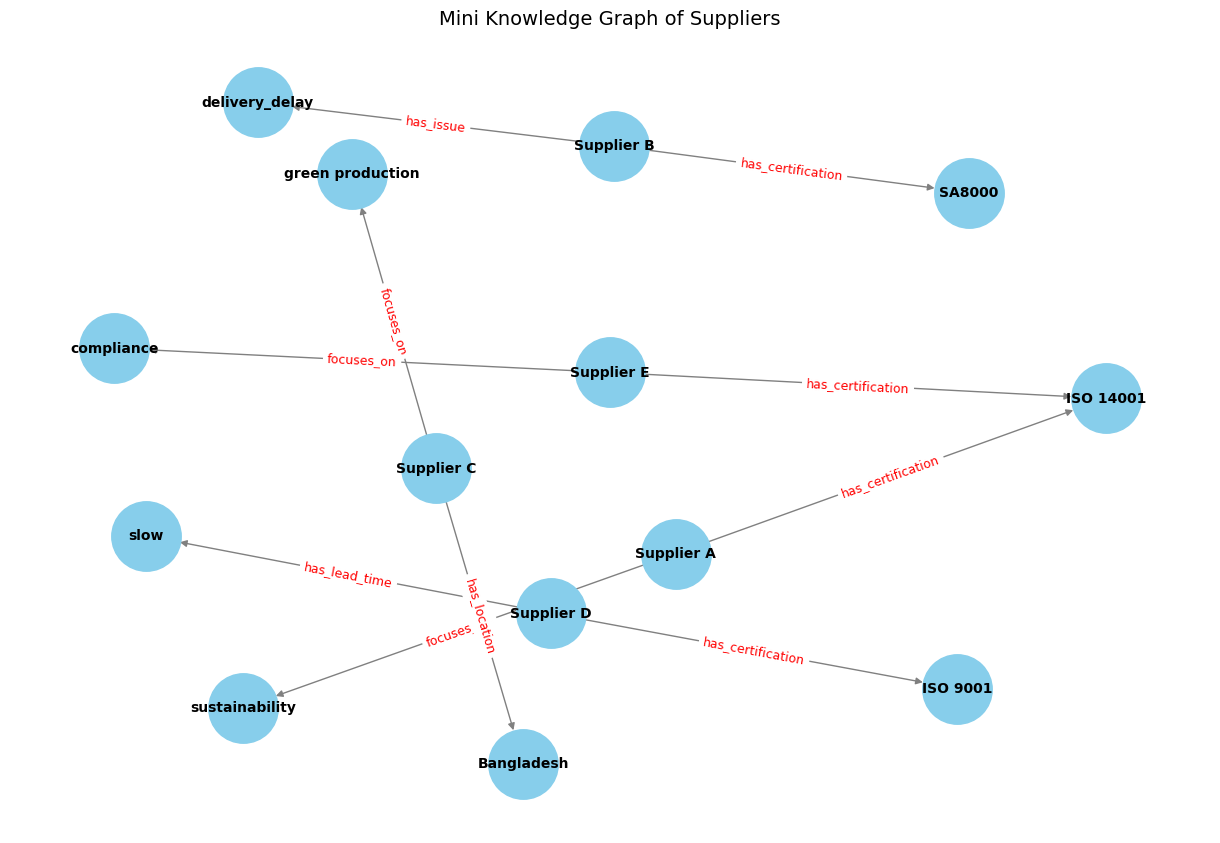

In [8]:
# Re-import after environment reset
!pip install networkx
import networkx as nx
import matplotlib.pyplot as plt

# Sample supplier relationships as triples (subject, predicate, object)
triples = [
    ("Supplier A", "has_certification", "ISO 14001"),
    ("Supplier A", "focuses_on", "sustainability"),
    ("Supplier B", "has_certification", "SA8000"),
    ("Supplier B", "has_issue", "delivery_delay"),
    ("Supplier C", "has_location", "Bangladesh"),
    ("Supplier C", "focuses_on", "green production"),
    ("Supplier D", "has_certification", "ISO 9001"),
    ("Supplier D", "has_lead_time", "slow"),
    ("Supplier E", "has_certification", "ISO 14001"),
    ("Supplier E", "focuses_on", "compliance"),
]

# Create a directed graph
G = nx.DiGraph()

# Add edges and nodes from triples
for subj, pred, obj in triples:
    G.add_edge(subj, obj, label=pred)

# Set positions
pos = nx.spring_layout(G, seed=42)

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2500, edge_color='gray', font_size=10, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=9)
plt.title("Mini Knowledge Graph of Suppliers", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()


ImportError: cannot import name 'abbrev_to_npy_unit' from 'pandas._libs.tslibs.dtypes' (C:\Users\srahman3\AppData\Local\anaconda3\envs\onx\lib\site-packages\pandas\_libs\tslibs\dtypes.cp38-win_amd64.pyd)

ImportError: cannot import name 'abbrev_to_npy_unit' from 'pandas._libs.tslibs.dtypes' (C:\Users\srahman3\AppData\Local\anaconda3\envs\onx\lib\site-packages\pandas\_libs\tslibs\dtypes.cp38-win_amd64.pyd)

                              Supplier  Score  sustainability  reliability  \
0   Jiangsu Hengli Hydraulic (Molding)      4               1            1   
1                            DME China      4               1            1   
2                         Yizumi Group      4               1            1   
3               Guangzhou Haoran Mould      3               0            0   
4        Zhejiang Sino Mould Co., Ltd.      3               0            1   
..                                 ...    ...             ...          ...   
95        Asian Mould Cluster (Suzhou)      0               0            0   
96       Shenzhen MeiDe Precision Tech      0               0            0   
97      Kaiping Walsun Mould Co., Ltd.      0               0            0   
98     Taiwan Plastic Mould (Shenzhen)      0               0            0   
99               Hangzhou Mekell Mould      0               0            0   

    iso_cert  lead_time  quality  price  
0          0         

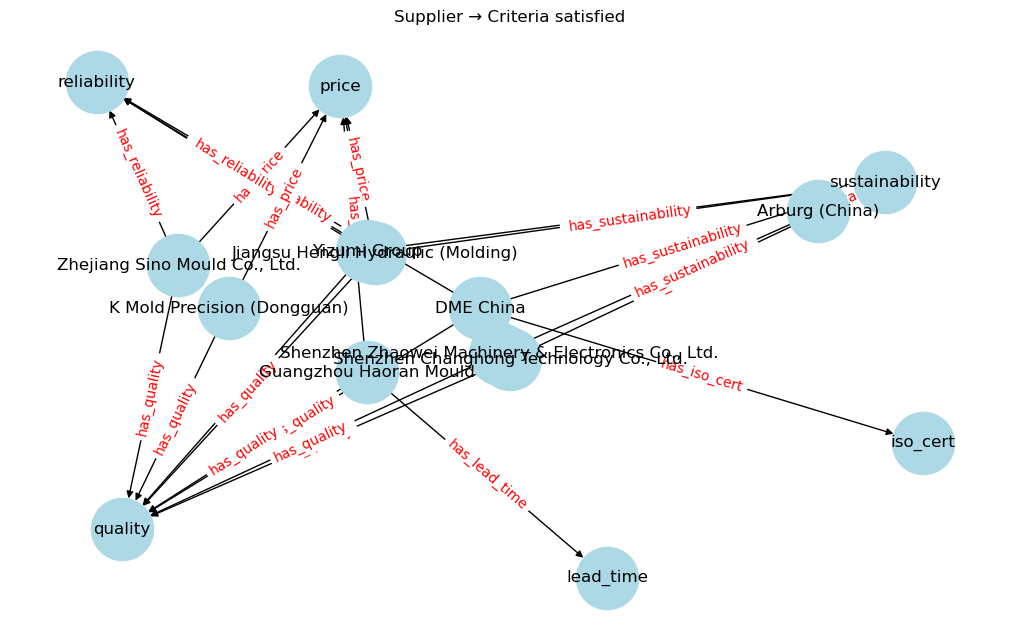

In [11]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣ Load and rename
df = pd.read_excel(r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx")
# Your sheet has columns ['#', 'Company', 'Website']
df = df.rename(columns={
    "Company": "Supplier",
    "Website": "Website"  # already correct
})

# 2️⃣ Define your six criteria
criteria_patterns = {
    "sustainability": ["sustainability","green","eco","environment"],
    "reliability"   : ["reliability","reliable","uptime"],
    "iso_cert"      : ["iso 9001","iso 14001","iso","certified"],
    "lead_time"     : ["lead time","lead-time","leadtime"],
    "quality"       : ["quality"],
    "price"         : ["price","cost","pricing"]
}

def score_website(url):
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except:
        text = ""
    return {crit: int(any(pat in text for pat in pats))
            for crit,pats in criteria_patterns.items()}

# 3️⃣ Build KG & collect scores
G = nx.DiGraph()
records = []
for _, row in df.iterrows():
    sup = row["Supplier"]
    site = row["Website"]
    scores = score_website(site)
    total = sum(scores.values())
    rec = {"Supplier": sup, "Score": total}
    rec.update(scores)
    records.append(rec)
    for crit,flag in scores.items():
        if flag:
            G.add_edge(sup, crit, label=f"has_{crit}")

# 4️⃣ Rank
ranked = pd.DataFrame(records).sort_values("Score", ascending=False).reset_index(drop=True)
print(ranked)

# 5️⃣ Draw mini‐KG
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red")
plt.title("Supplier → Criteria satisfied")
plt.axis('off')
plt.show()



🏆 Top 10 Suppliers by Hit-Count Score:
                                          Supplier  Score  sustainability  reliability  iso_cert  lead_time  quality  price
                Jiangsu Hengli Hydraulic (Molding)      4               1            1         0          0        1      1
                                         DME China      4               1            1         1          0        1      0
                                      Yizumi Group      4               1            1         0          0        1      1
                            Guangzhou Haoran Mould      3               0            0         0          1        1      1
                     Zhejiang Sino Mould Co., Ltd.      3               0            1         0          0        1      1
                       K Mold Precision (Dongguan)      2               0            0         0          0        1      1
           Shenzhen Changhong Technology Co., Ltd.      2               1            0      

C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


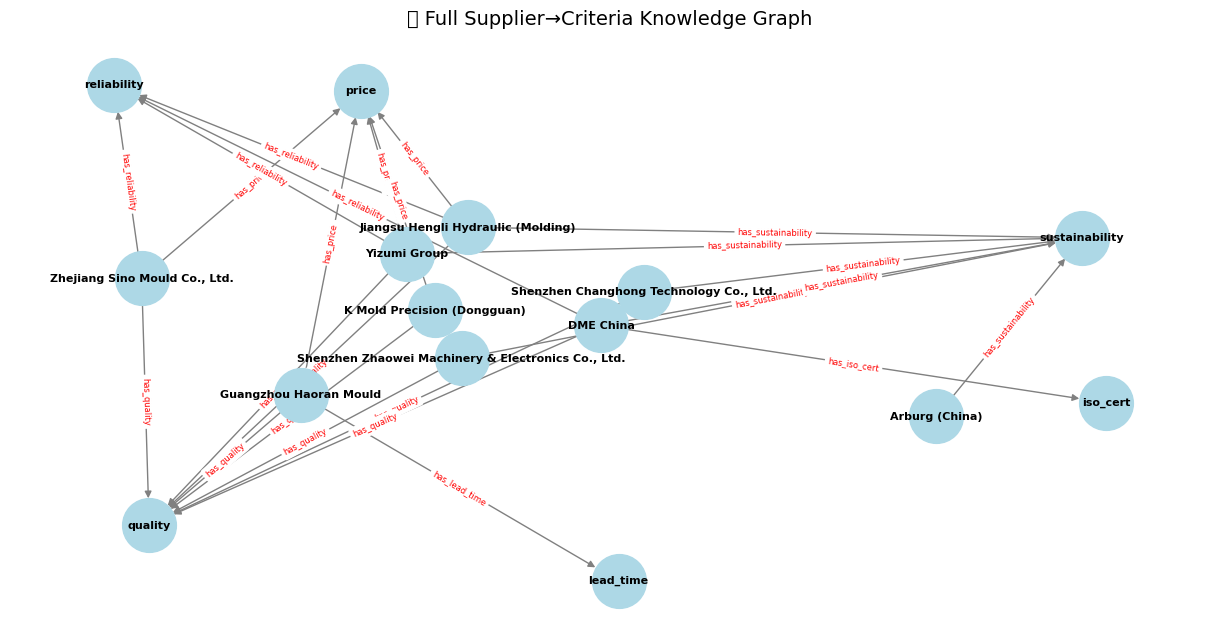

C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128278 (\N{BOOKMARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


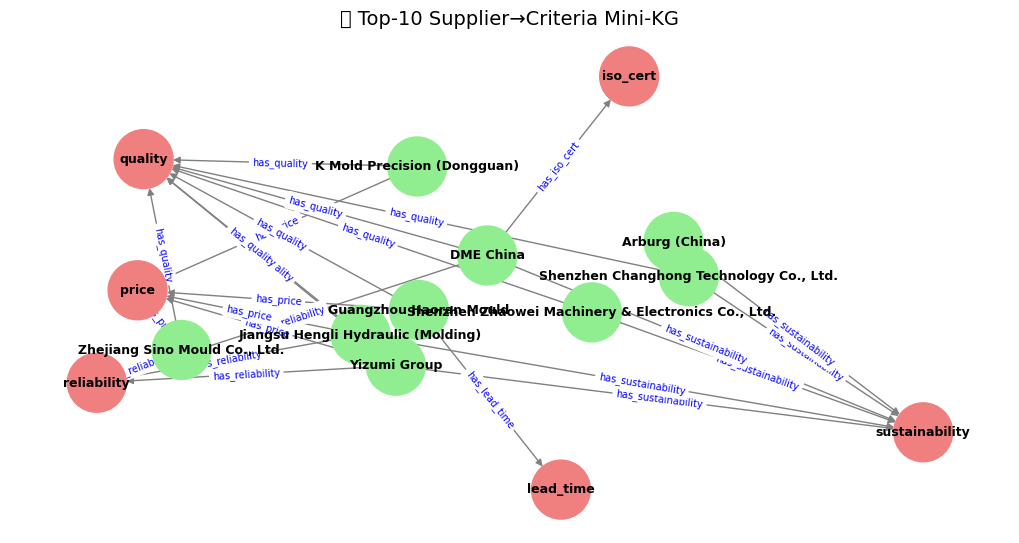

In [13]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣ Load and rename
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)
df = df.rename(columns={
    "Company": "Supplier",
    # "Website" column is already called "Website"
})

# 2️⃣ Define your six criteria (keywords to look for on each site)
criteria_patterns = {
    "sustainability": ["sustainability", "green", "eco", "environment"],
    "reliability"   : ["reliability", "reliable", "uptime"],
    "iso_cert"      : ["iso 9001", "iso 14001", "iso", "certified"],
    "lead_time"     : ["lead time", "lead-time", "leadtime"],
    "quality"       : ["quality"],
    "price"         : ["price", "cost", "pricing"]
}

def score_website(url):
    """Fetch the page, lowercase it, and flag each criterion if any keyword is found."""
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    # return a dict of 0/1 flags
    return {crit: int(any(pat in text for pat in pats))
            for crit, pats in criteria_patterns.items()}

# 3️⃣ Score *all* suppliers and build the full KG
G_full = nx.DiGraph()
records = []

for _, row in df.iterrows():
    sup  = row["Supplier"]
    site = row["Website"]
    scores = score_website(site)
    total  = sum(scores.values())

    # record for DataFrame
    rec = {"Supplier": sup, "Score": total}
    rec.update(scores)
    records.append(rec)

    # add edges for each satisfied criterion
    for crit, flag in scores.items():
        if flag:
            G_full.add_edge(sup, crit, label=f"has_{crit}")

# 4️⃣ Build & display the full ranking
ranked = pd.DataFrame(records).sort_values("Score", ascending=False).reset_index(drop=True)
print("\n🏆 Top 10 Suppliers by Hit-Count Score:")
print(ranked.head(10).to_string(index=False))

# 5️⃣ Draw the **full** KG
plt.figure(figsize=(12, 6))
pos = nx.spring_layout(G_full, seed=42, k=1.0)
nx.draw(G_full, pos,
        with_labels=True,
        node_size=1500,
        node_color="lightblue",
        font_size=8,
        font_weight="bold",
        edge_color="gray")
edge_labels = nx.get_edge_attributes(G_full, 'label')
nx.draw_networkx_edge_labels(G_full, pos, edge_labels=edge_labels, font_color="red", font_size=6)
plt.title("🔗 Full Supplier→Criteria Knowledge Graph", fontsize=14)
plt.axis('off')
plt.show()

# 6️⃣ Extract Top-10 subset and draw their mini-KG
top10 = ranked.head(10)["Supplier"].tolist()
G_top10 = G_full.subgraph(top10 + list(criteria_patterns.keys())).copy()

plt.figure(figsize=(10, 5))
pos = nx.spring_layout(G_top10, seed=24, k=1.0)
nx.draw(G_top10, pos,
        with_labels=True,
        node_size=1800,
        node_color=["lightgreen" if n in top10 else "lightcoral" for n in G_top10.nodes()],
        font_size=9,
        font_weight="bold",
        edge_color="gray")
edge_labels = nx.get_edge_attributes(G_top10, 'label')
nx.draw_networkx_edge_labels(G_top10, pos, edge_labels=edge_labels, font_color="blue", font_size=7)
plt.title("🔖 Top-10 Supplier→Criteria Mini-KG", fontsize=14)
plt.axis('off')
plt.show()



🏆 Top 10 Suppliers by WeightedScore:
 SL                                           Supplier  WeightedScore  sustainability  reliability  iso_cert  lead_time  quality  price
  3                                          DME China           0.90               1            1         1          0        1      0
 34                 Jiangsu Hengli Hydraulic (Molding)           0.89               1            1         0          0        1      1
 24                                       Yizumi Group           0.89               1            1         0          0        1      1
 97                                 Foshan Knight Mold           0.84               1            1         0          0        1      0
 55                             Jiangsu Sumech Machine           0.60               1            0         1          0        1      0
  1            Shenzhen Changhong Technology Co., Ltd.           0.54               1            0         0          0        1      0
  2 Shenzh

C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128278 (\N{BOOKMARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


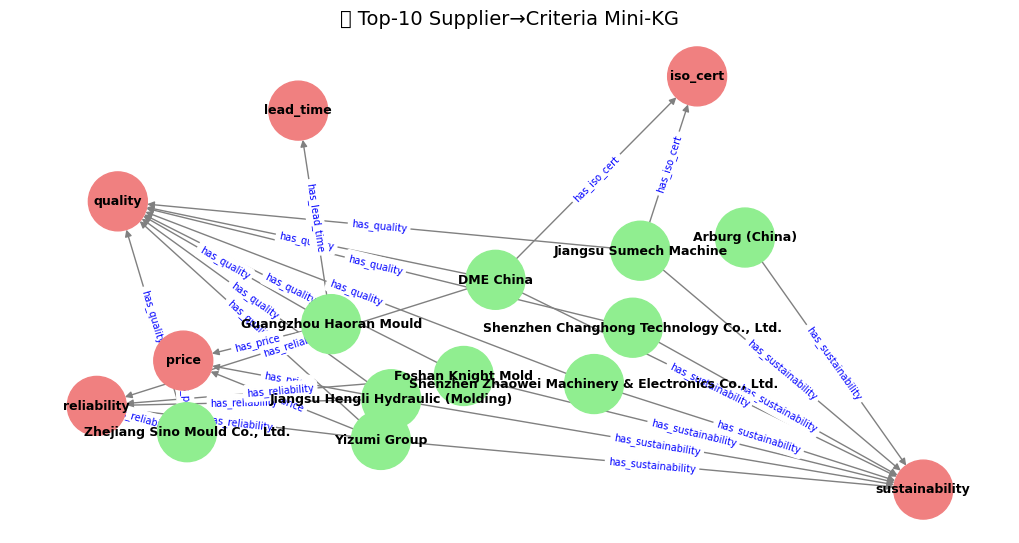

In [73]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣ Load & rename (grab the "#" column as "ID")
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)
df = df.rename(columns={
    "#":        "SL",
    "Company":  "Supplier",
    # "Website" stays as-is
})

# 2️⃣ Define your six criteria → binary flags
criteria_patterns = {
    "sustainability": ["sustainability", "green", "eco", "environment"],
    "reliability"   : ["reliability", "reliable", "uptime", "good Feedback"],
    "iso_cert"      : ["iso 9001", "iso 14001", "iso", "certified"],
    "lead_time"     : ["lead time", "lead-time", "leadtime","delivery time",],
    "quality"       : ["quality","technical","precision",],
    "price"         : ["price", "cost", "pricing"],
   
}

# 3️⃣ Assign weights that sum to 1
criteria_weights = {
    "sustainability": 0.50,
    "reliability"   : 0.30,
    "iso_cert"      : 0.06,
    "lead_time"     : 0.05,
    "quality"       : 0.04,
    "price"         : 0.05,
   
}

def score_website(url):
    """Fetch page text, lowercase, then flag each criterion if any pattern matches."""
    try:
        html = requests.get(url, timeout=8).text
        text = BeautifulSoup(html, "html.parser")\
                  .get_text(" ")\
                  .lower()
    except Exception:
        text = ""
    return {
        crit: int(any(pat in text for pat in pats))
        for crit, pats in criteria_patterns.items()
    }

# 4️⃣ Score *all* suppliers, compute weighted score
records = []
G_full = nx.DiGraph()

for _, row in df.iterrows():
    sup  = row["Supplier"]
    site = row["Website"]
    idx  = row["SL"]
    flags = score_website(site)

    # weighted sum
    weighted = sum(flags[c] * criteria_weights[c] for c in flags)

    rec = {
        "SL":            idx,
        "Supplier":      sup,
        "WeightedScore": weighted
    }
    rec.update(flags)
    records.append(rec)

    # (optional) Build KG edges
    for crit, flag in flags.items():
        if flag:
            G_full.add_edge(sup, crit, label=f"has_{crit}")

# 5️⃣ Rank by WeightedScore
ranked = (
    pd.DataFrame(records)
      .sort_values("WeightedScore", ascending=False)
      .reset_index(drop=True)
)

print("\n🏆 Top 10 Suppliers by WeightedScore:")
print(
    ranked
      .head(10)
      .loc[:, ["SL","Supplier","WeightedScore"] + list(criteria_patterns.keys())]
      .to_string(index=False)
)

# 6️⃣ (Optional) Draw mini‐KG for just the top-10
top10 = ranked.head(10)["Supplier"].tolist()
G_top10 = G_full.subgraph(top10 + list(criteria_patterns.keys())).copy()

plt.figure(figsize=(10,5))
pos = nx.spring_layout(G_top10, seed=24, k=1.0)
nx.draw(
    G_top10, pos, with_labels=True,
    node_size=1800,
    node_color=[
        "lightgreen" if n in top10 else "lightcoral" 
        for n in G_top10.nodes()
    ],
    font_size=9, font_weight="bold", edge_color="gray"
)
edge_labels = nx.get_edge_attributes(G_top10,'label')
nx.draw_networkx_edge_labels(
    G_top10, pos, edge_labels=edge_labels,
    font_color="blue", font_size=7
)
plt.title("🔖 Top-10 Supplier→Criteria Mini-KG", fontsize=14)
plt.axis('off')
plt.show()


In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import random

# === Load supplier list ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)

# Rename if needed
df = df.rename(columns={"Company": "Supplier"})

# === Criteria patterns ===
criteria_patterns = {
    "sustainability": ["sustainability", "green", "eco", "environment"],
    "reliability"   : ["reliability", "reliable", "uptime"],
    "iso_cert"      : ["iso 9001", "iso 14001", "iso", "certified"],
    "lead_time"     : ["lead time", "lead-time", "leadtime"],
    "quality"       : ["quality"],
    "price"         : ["price", "cost", "pricing"]
}

# === Updated function to also return raw text ===
def score_website(url):
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    flags = {crit: int(any(pat in text for pat in pats))
             for crit, pats in criteria_patterns.items()}
    return flags, text

# === Choose 3 random suppliers for text capture ===
sample_suppliers = df.sample(3, random_state=42)

# Store example texts
example_texts = []

for _, row in sample_suppliers.iterrows():
    supplier = row["Supplier"]
    site = row["Website"]
    
    flags, raw_text = score_website(site)
    
    example_texts.append(f"=== {supplier} ===\nWebsite: {site}\nFlags: {flags}\n\nExtracted Text:\n{raw_text[:2000]}...\n\n")

# === Save example texts to file ===
example_file_path = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier_example_texts.txt"
with open(example_file_path, "w", encoding="utf-8") as f:
    f.writelines(example_texts)

print(f"✅ Example texts saved to: {example_file_path}")


✅ Example texts saved to: C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier_example_texts.txt


In [3]:
import os
import pandas as pd
import requests
from bs4 import BeautifulSoup

# === Load supplier list ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)

# Rename if needed
df = df.rename(columns={"Company": "Supplier"})

# === Criteria patterns ===
criteria_patterns = {
    "sustainability": ["sustainability", "green", "eco", "environment"],
    "reliability"   : ["reliability", "reliable", "uptime"],
    "iso_cert"      : ["iso 9001", "iso 14001", "iso", "certified"],
    "lead_time"     : ["lead time", "lead-time", "leadtime"],
    "quality"       : ["quality"],
    "price"         : ["price", "cost", "pricing"]
}

# === Updated function to return both flags and raw text ===
def score_website(url):
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    flags = {crit: int(any(pat in text for pat in pats))
             for crit, pats in criteria_patterns.items()}
    return flags, text

# === Create output folder for supplier texts ===
output_folder = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier_texts"
os.makedirs(output_folder, exist_ok=True)

# === Loop through all suppliers ===
for _, row in df.iterrows():
    supplier = str(row["Supplier"]).strip()
    site = str(row["Website"]).strip()
    
    flags, raw_text = score_website(site)
    
    # Create filename safe for file system
    safe_name = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in supplier)[:50]
    file_path = os.path.join(output_folder, f"{safe_name}.txt")
    
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"Supplier: {supplier}\n")
        f.write(f"Website: {site}\n")
        f.write(f"Flags: {flags}\n\n")
        f.write("=== Extracted Text ===\n")
        f.write(raw_text)
    
    print(f"✅ Saved text for: {supplier}")

print(f"\n🎯 All supplier texts saved in: {output_folder}")


✅ Saved text for: Shenzhen Changhong Technology Co., Ltd.
✅ Saved text for: Shenzhen Zhaowei Machinery & Electronics Co., Ltd.
✅ Saved text for: DME China
✅ Saved text for: CFS Mold (Shenzhen)
✅ Saved text for: Sunbright Plastic Technology (Dongguan)
✅ Saved text for: Dongguan Goldenmold Precision Mould Co., Ltd.
✅ Saved text for: Shenzhen Jesun Mould Plastic Product Co., Ltd.
✅ Saved text for: Suzhou Youfier Precision Mold Co., Ltd.
✅ Saved text for: Epic Mould (Dongguan)
✅ Saved text for: Yongjia Mold Co., Ltd. (Wenzhou)
✅ Saved text for: HWM Technology Co., Ltd. (Kunshan)
✅ Saved text for: Erowa China (Shanghai)
✅ Saved text for: Meusburger (China)
✅ Saved text for: Haixin Mould (Dongguan)
✅ Saved text for: J812 Mould Industry (Suzhou)
✅ Saved text for: Zhejiang Sino Mould Co., Ltd.
✅ Saved text for: Shenzhen Red Star Mould Co., Ltd.
✅ Saved text for: Kingswell USA (China HQ)
✅ Saved text for: Huarui Precision Mould (Wuxi)
✅ Saved text for: Arburg (China)
✅ Saved text for: Haitian P

In [5]:
import os
import pandas as pd
import requests
from bs4 import BeautifulSoup

# === Load supplier list ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)

# Rename columns if necessary
df = df.rename(columns={"Company": "Supplier"})

# === Criteria patterns ===
criteria_patterns = {
    "sustainability": ["sustainability", "green", "eco", "environment"],
    "reliability"   : ["reliability", "reliable", "uptime"],
    "iso_cert"      : ["iso 9001", "iso 14001", "iso", "certified"],
    "lead_time"     : ["lead time", "lead-time", "leadtime"],
    "quality"       : ["quality"],
    "price"         : ["price", "cost", "pricing"]
}

# === Function to get flags + raw text ===
def score_website(url):
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    flags = {crit: int(any(pat in text for pat in pats))
             for crit, pats in criteria_patterns.items()}
    return flags, text

# === Output folder for supplier text files ===
output_folder = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier_texts"
os.makedirs(output_folder, exist_ok=True)

# === List to store CSV summary ===
summary_records = []

# === Loop through suppliers ===
for _, row in df.iterrows():
    supplier = str(row["Supplier"]).strip()
    site = str(row["Website"]).strip()
    
    flags, raw_text = score_website(site)
    total_score = sum(flags.values())
    
    # Save text file for each supplier
    safe_name = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in supplier)[:50]
    file_path = os.path.join(output_folder, f"{safe_name}.txt")
    
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"Supplier: {supplier}\n")
        f.write(f"Website: {site}\n")
        f.write(f"Flags: {flags}\n")
        f.write(f"Total Score: {total_score}\n\n")
        f.write("=== Extracted Text ===\n")
        f.write(raw_text)
    
    # Add to summary list
    summary_record = {"Supplier": supplier, "Website": site, "Total Score": total_score}
    summary_record.update(flags)
    summary_records.append(summary_record)
    
    print(f"✅ Processed: {supplier}")

# === Create summary DataFrame and save to CSV ===
summary_df = pd.DataFrame(summary_records)
summary_csv_path = os.path.join(output_folder, "Supplier_Criteria_Summary.csv")
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8")

print(f"\n📄 Summary CSV saved at: {summary_csv_path}")
print(f"📂 Individual supplier text files saved in: {output_folder}")


✅ Processed: Shenzhen Changhong Technology Co., Ltd.
✅ Processed: Shenzhen Zhaowei Machinery & Electronics Co., Ltd.
✅ Processed: DME China
✅ Processed: CFS Mold (Shenzhen)
✅ Processed: Sunbright Plastic Technology (Dongguan)
✅ Processed: Dongguan Goldenmold Precision Mould Co., Ltd.
✅ Processed: Shenzhen Jesun Mould Plastic Product Co., Ltd.
✅ Processed: Suzhou Youfier Precision Mold Co., Ltd.
✅ Processed: Epic Mould (Dongguan)
✅ Processed: Yongjia Mold Co., Ltd. (Wenzhou)
✅ Processed: HWM Technology Co., Ltd. (Kunshan)
✅ Processed: Erowa China (Shanghai)
✅ Processed: Meusburger (China)
✅ Processed: Haixin Mould (Dongguan)
✅ Processed: J812 Mould Industry (Suzhou)
✅ Processed: Zhejiang Sino Mould Co., Ltd.
✅ Processed: Shenzhen Red Star Mould Co., Ltd.
✅ Processed: Kingswell USA (China HQ)
✅ Processed: Huarui Precision Mould (Wuxi)
✅ Processed: Arburg (China)
✅ Processed: Haitian Plastics Machinery (Ningbo)
✅ Processed: Wittmann Battenfeld (China)
✅ Processed: Sumitomo (SHI) Demag (Ch

In [7]:
import networkx as nx
import pandas as pd

# Build a simple KG
G = nx.DiGraph()

# Supplier-criteria edges (from your table)
edges = [
    ("Jiangsu Hengli", "sustainability"),
    ("Jiangsu Hengli", "ISO cert"),
    ("Jiangsu Hengli", "price"),
    ("DME China", "ISO cert"),
    ("DME China", "reliability"),
    ("DME China", "price"),
    ("Yizumi Group", "ISO cert"),
    ("Yizumi Group", "price"),
    ("Guangzhou Haoran", "sustainability"),
    ("Zhejiang Sino", "ISO cert"),
]

# Add edges to graph
G.add_edges_from(edges)

# Compute PageRank
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Convert to DataFrame
df_pagerank = pd.DataFrame(pagerank_scores.items(), columns=["Node", "PageRank"])
df_suppliers = df_pagerank[df_pagerank["Node"].isin(["Jiangsu Hengli", "DME China", "Yizumi Group", "Guangzhou Haoran", "Zhejiang Sino"])]
df_suppliers = df_suppliers.sort_values(by="PageRank", ascending=False)

print(df_suppliers)


               Node  PageRank
0    Jiangsu Hengli  0.075472
4         DME China  0.075472
6      Yizumi Group  0.075472
7  Guangzhou Haoran  0.075472
8     Zhejiang Sino  0.075472


Computing transition probabilities:   0%|          | 0/19 [00:00<?, ?it/s]

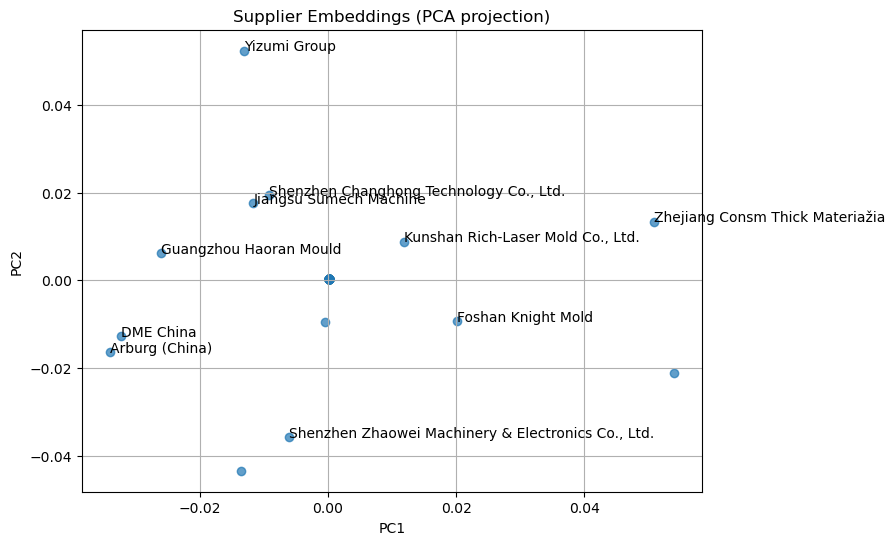


🏆 Top 10 Suppliers by KG + PageRank + Embedding:
                                          Supplier  delivery  quality  security  pricing  lead  sustainability  Weighted KG Score  PageRank  Final KG Score
                                         DME China         1        1         1        0     0               1               0.64  0.033278        0.673278
           Shenzhen Changhong Technology Co., Ltd.         0        1         1        0     0               1               0.59  0.033278        0.623278
Shenzhen Zhaowei Machinery & Electronics Co., Ltd.         0        1         1        0     0               1               0.59  0.033278        0.623278
                                      Yizumi Group         0        1         0        1     0               1               0.59  0.033278        0.623278
                                Foshan Knight Mold         0        1         0        0     0               1               0.54  0.033278        0.573278
              

In [21]:

!pip install node2vec
import pandas as pd
import requests
from bs4 import BeautifulSoup
import networkx as nx
from node2vec import Node2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# === Load and rename ===
df = pd.read_excel(
    r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\supplier list 100.xlsx"
)
df = df.rename(columns={"Company": "Supplier"})

# === Define criteria patterns ===
criteria_patterns = {
    "delivery": ["delivery", "fast delivery", "timely delivery"],
    "quality": ["quality", "high quality", "product quality"],
    "security": ["security", "secure", "cybersecurity", "compliance"],
    "pricing": ["price", "cost", "pricing", "low cost"],
    "lead": ["lead time", "lead-time", "leadtime"],
    "sustainability": ["sustainability", "green", "eco", "environment"]
}

# === Criteria weights ===
criteria_weights = {
    "sustainability": 0.50,
    "reliability": 0.30,
    "iso_cert": 0.06,
    "lead": 0.05,
    "quality": 0.04,
    "price": 0.05
}

def score_website(url):
    """Fetch text from website and check keywords."""
    try:
        r = requests.get(url, timeout=10)
        text = BeautifulSoup(r.text, "html.parser").get_text(" ").lower()
    except Exception:
        text = ""
    return {crit: int(any(pat in text for pat in pats))
            for crit, pats in criteria_patterns.items()}

# === Build full KG ===
G_full = nx.DiGraph()
records = []

for _, row in df.iterrows():
    sup  = row["Supplier"]
    site = row["Website"]
    scores = score_website(site)
    
    weighted_score = sum(scores.get(c, 0) * criteria_weights.get(c, 0.05) for c in scores)
    
    rec = {"Supplier": sup, "Weighted KG Score": weighted_score}
    rec.update(scores)
    records.append(rec)

    for crit, flag in scores.items():
        if flag:
            G_full.add_edge(sup, crit, label=f"has_{crit}")

# === PageRank Integration ===
pagerank_scores = nx.pagerank(G_full)
for rec in records:
    rec["PageRank"] = pagerank_scores.get(rec["Supplier"], 0)

# === Final KG Score ===
for rec in records:
    rec["Final KG Score"] = rec["Weighted KG Score"] + rec["PageRank"]

# === Graph Embedding Phase (Node2Vec) ===
node2vec = Node2Vec(G_full, dimensions=64, walk_length=20, num_walks=100, workers=2, seed=42)
embedding_model = node2vec.fit(window=10, min_count=1, batch_words=4)

for rec in records:
    supplier = rec["Supplier"]
    if supplier in embedding_model.wv:
        embedding_vector = embedding_model.wv[supplier]
        for i, val in enumerate(embedding_vector):
            rec[f"emb_{i}"] = val
    else:
        for i in range(64):
            rec[f"emb_{i}"] = 0.0

# === Create DataFrame ===
ranked = pd.DataFrame(records).sort_values("Final KG Score", ascending=False).reset_index(drop=True)

# === PCA Visualization of Embeddings ===
X = ranked[[f"emb_{i}" for i in range(64)]].values
X_2D = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_2D[:, 0], X_2D[:, 1], alpha=0.7)
for i, txt in enumerate(ranked["Supplier"].head(10)):
    plt.annotate(txt, (X_2D[i, 0], X_2D[i, 1]))
plt.title("Supplier Embeddings (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# === Top 10 Suppliers ===
cols_to_display = ["Supplier", "delivery", "quality", "security", "pricing", "lead", "sustainability",
                   "Weighted KG Score", "PageRank", "Final KG Score"]
print("\n🏆 Top 10 Suppliers by KG + PageRank + Embedding:")
print(ranked[cols_to_display].head(10).to_string(index=False))


In [66]:
import pandas as pd

# 1. Load the original log
in_path = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\Supplier_Disruption.csv"
df = pd.read_csv(in_path)

# 2. Compute a “high_disruption_prob” as downtime_hours normalized by the max observed downtime
max_downtime = df['downtime_hours'].max()
df['high_disruption_prob'] = df['downtime_hours'] / max_downtime

# 3. Save out the augmented table
out_path = r"Supplier_Disruption_Probabilities.csv"
df.to_csv(out_path, index=False)

# 4. Quick sanity check: print the first 10 rows with the new column
print(df.head(10))



         date                  supplier  kg_score  twitter_alert  \
0  2025-01-01  Jiangsu Hengli Hydraulic      0.00              1   
1  2025-01-02  Jiangsu Hengli Hydraulic      0.71              0   
2  2025-01-03  Jiangsu Hengli Hydraulic      0.30              0   
3  2025-01-04  Jiangsu Hengli Hydraulic      0.00              0   
4  2025-01-05  Jiangsu Hengli Hydraulic      0.07              1   
5  2025-01-06  Jiangsu Hengli Hydraulic      0.00              0   
6  2025-01-07  Jiangsu Hengli Hydraulic      0.55              1   
7  2025-01-08  Jiangsu Hengli Hydraulic      0.00              0   
8  2025-01-09  Jiangsu Hengli Hydraulic      0.00              0   
9  2025-01-10  Jiangsu Hengli Hydraulic      0.00              0   

   weather_risk  economic_risk  geo_risk  tech_risk  downtime_hours  \
0             0              0         0          0             4.0   
1             1              0         0          0             7.8   
2             0              0        

In [166]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ─── 1) Load your data ───────────────────────────────────────────────────────
# if CSV:
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# if Excel instead, comment out above and uncomment:
# df = pd.read_excel(DATA_PATH, parse_dates=["date"])

# ─── 2) Binarize your continuous target ─────────────────────────────────────
# We had high_disruption_prob ∈ [0,1].  Here we threshold at 0.5
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.2).astype(int)

# ─── 3) Define features X and label y ────────────────────────────────────────
# drop “date” (time ordering) or you can extract day‐of‐week etc.
X = df[[
    "supplier",
    "kg_score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
]]
y = df["high_disruption_label"]

# ─── 4) Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.8,      # e.g. 60/40 split
    stratify=y,
    random_state=42,
)

# ─── 5) Build preprocessing pipeline ─────────────────────────────────────────
# numeric features to scale
num_cols = ["kg_score", "downtime_hours"]
# categorical features to one‐hot
cat_cols = ["supplier"]
# leave the 0/1 risk‐flags through passthrough
pass_cols = [
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"  # passes the pass_cols unchanged
)

# ─── 6) Helper to build, train, evaluate ──────────────────────────────────────
def build_and_evaluate(model, name):
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ─── 7) Train & evaluate ─────────────────────────────────────────────────────
build_and_evaluate(LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression")
build_and_evaluate(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")
build_and_evaluate(GradientBoostingClassifier(n_estimators=100, random_state=42), "Gradient Boosting")

# ─── 8) (Optional) Quick hyper‐parameter search on RF ─────────────────────────
param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [None, 5, 10]
}
grid = GridSearchCV(
    Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(random_state=42))]),
    param_grid, cv=3, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)
print("\n=== RF Grid Search Best ===")
print(grid.best_params_, f"ROC-AUC={grid.best_score_:.3f}")


ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1

In [86]:
# ─── Supplier‐level Ranking by Predicted Disruption Risk ──────────────────────
from sklearn.pipeline import Pipeline

# 1) Rebuild the full‐data pipeline + best classifier (here: the tuned RandomForest)
best_rf = RandomForestClassifier(
    n_estimators=grid.best_params_['clf__n_estimators'],
    max_depth=  grid.best_params_['clf__max_depth'],
    random_state=42
)
full_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", best_rf)
])
# 2) Fit on all available data
full_pipe.fit(X, y)

# 3) Score every row → disruption probability
df["pred_prob"] = full_pipe.predict_proba(X)[:,1]

# 4) Average per supplier, sort descending
supplier_ranking = (
    df
    .groupby("supplier")["pred_prob"]
    .mean()
    .reset_index(name="avg_disruption_prob")
    .sort_values("avg_disruption_prob", ascending=False)
    .reset_index(drop=True)
)

print("=== Supplier Ranking by Mean Predicted Disruption Risk ===")
print(supplier_ranking.head(10))


=== Supplier Ranking by Mean Predicted Disruption Risk ===
                   supplier  avg_disruption_prob
0              Yizumi Group             0.590186
1          K Mold Precision             0.554647
2   Shenzhen Changhong Tech             0.545971
3  Jiangsu Hengli Hydraulic             0.530497
4       Zhejiang Sino Mould             0.475595
5     Shenzhen Zhaowei Mech             0.465309
6    Guangzhou Haoran Mould             0.455070
7                 DME China             0.446635
8              Arburg China             0.438089
9         Yangzhou Hongbang             0.408714


In [93]:
import pandas as pd
import joblib

# 1) Load the trained pipeline
model = joblib.load("logreg_supplier_disruption.joblib")

# 2) Prepare your new-data as a DataFrame
#    Make sure the columns exactly match your training X columns
#    (supplier, kg_score, twitter_alert, weather_risk, economic_risk, geo_risk, tech_risk, downtime_hours)
new_data = pd.DataFrame([
    {
        "supplier":      "Jiangsu Hengli Hydraulic (Molding)",
        "kg_score":      0.2,
        "twitter_alert": 1,
        "weather_risk":  1,
        "economic_risk": 0,
        "geo_risk":      0,
        "tech_risk":     0,
        "downtime_hours":8
    },
    {
        "supplier":      "DME China",
        "kg_score":      0.5,
        "twitter_alert": 0,
        "weather_risk":  1,
        "economic_risk": 0,
        "geo_risk":      0,
        "tech_risk":     0,
        "downtime_hours": 4
    },
    # … you can append as many rows as you like
])

# 3) Predict class (0=no, 1=high disruption) and probability
pred_class = model.predict(new_data)
pred_proba = model.predict_proba(new_data)[:,1]  # probability of class “1”

# 4) Show results
results = new_data.copy()
results["predicted_label"] = pred_class
results["disruption_prob"]  = pred_proba
print(results)



                             supplier  kg_score  twitter_alert  weather_risk  \
0  Jiangsu Hengli Hydraulic (Molding)       0.2              1             1   
1                           DME China       0.5              0             1   

   economic_risk  geo_risk  tech_risk  downtime_hours  predicted_label  \
0              0         0          0               8                1   
1              0         0          0               4                0   

   disruption_prob  
0         0.833214  
1         0.023828  


In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection    import train_test_split, GridSearchCV
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.metrics            import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.neural_network     import MLPClassifier
import joblib

# ─── 1) Load & binarize ─────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# ─── 2) Features & label ─────────────────────────────────────────────────────────
X = df[[
    "supplier",
    "kg_score",
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours",
]]
y = df["high_disruption_label"]

# ─── 3) Train/test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.8,  # 60/40 split
    stratify=y, random_state=95
)

# ─── 4) Preprocessing ───────────────────────────────────────────────────────────
num_cols = ["kg_score", "downtime_hours"]
cat_cols = ["supplier"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num",    StandardScaler(),                  num_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ─── 5) Build the MLP pipeline ─────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,               # L2 penalty (weight decay)
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=95
)

pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", mlp),
])

# ─── 6) Train & evaluate ───────────────────────────────────────────────────────
pipe.fit(X_train, y_train)
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

print("\n=== MLPClassifier (scikit-learn) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

# ─── 7) Save model & preprocessor ────────────────────────────────────────────────
joblib.dump(pipe, "mlp_supplier_disruption.joblib")
print("☑️  Saved MLPClassifier pipeline to mlp_supplier_disruption.joblib")



=== MLPClassifier (scikit-learn) ===
Confusion Matrix:
[[354  48]
 [ 24  54]]

Classification Report:
              precision    recall  f1-score   support

           0      0.937     0.881     0.908       402
           1      0.529     0.692     0.600        78

    accuracy                          0.850       480
   macro avg      0.733     0.786     0.754       480
weighted avg      0.870     0.850     0.858       480

ROC-AUC: 0.874
☑️  Saved MLPClassifier pipeline to mlp_supplier_disruption.joblib


In [88]:
import pandas as pd
import joblib

# 1) Load the trained pipeline
model = joblib.load("mlp_supplier_disruption.joblib")

# 2) Prepare your new-data as a DataFrame
#    Make sure the columns exactly match your training X columns
#    (supplier, kg_score, twitter_alert, weather_risk, economic_risk, geo_risk, tech_risk, downtime_hours)
new_data = pd.DataFrame([
    {
        "supplier":      "Supplier A)",
        "kg_score":      0.2,
        "twitter_alert": 1,
        "weather_risk":  1,
        "economic_risk": 0,
        "geo_risk":      0,
        "tech_risk":     0,
        "downtime_hours":8
    },
    {
        "supplier":      "supplier B",
        "kg_score":      0.5,
        "twitter_alert": 0,
        "weather_risk":  1,
        "economic_risk": 0,
        "geo_risk":      0,
        "tech_risk":     0,
        "downtime_hours": 4
    },
    # … you can append as many rows as you like
])

# 3) Predict class (0=no, 1=high disruption) and probability
pred_class = model.predict(new_data)
pred_proba = model.predict_proba(new_data)[:,1]  # probability of class “1”

# 4) Show results
results = new_data.copy()
results["predicted_label"] = pred_class
results["disruption_prob"]  = pred_proba
print(results)


      supplier  kg_score  twitter_alert  weather_risk  economic_risk  \
0  Supplier A)       0.2              1             1              0   
1   supplier B       0.5              0             1              0   

   geo_risk  tech_risk  downtime_hours  predicted_label  disruption_prob  
0         0          0               8                1         0.537116  
1         0          0               4                0         0.448673  


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# === 1. Load dataset ===
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable22.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.6).astype(int)

# === 2. Features and target ===
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# === 3. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=65
)

# === 4. Preprocessing ===
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# Fit-transform preprocessing for train/test
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# === 5. Define models ===
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=45),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=45),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=45),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=95, eval_metric="logloss"),
}

# === 6. Train and evaluate ===
for name, model in models.items():
    model.fit(X_train_trans, y_train)
    y_proba = model.predict_proba(X_test_trans)[:, 1]

    mae = mean_absolute_error(y_test, y_proba)
    mse = mean_squared_error(y_test, y_proba)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print(f"MAE     : {mae:.6f}")
    print(f"MSE     : {mse:.6f}")
    print(f"RMSE    : {rmse:.6f}")
    print(f"R² Score: {r2:.6f}")



=== Logistic Regression ===
MAE     : 0.063162
MSE     : 0.019331
RMSE    : 0.139037
R² Score: 0.909355

=== Random Forest ===
MAE     : 0.085583
MSE     : 0.030731
RMSE    : 0.175302
R² Score: 0.855902

=== Gradient Boosting ===
MAE     : 0.035200
MSE     : 0.023306
RMSE    : 0.152663
R² Score: 0.890717

=== XGBoost ===
MAE     : 0.026915
MSE     : 0.014296
RMSE    : 0.119565
R² Score: 0.932966


In [38]:
severe_warnings = []
for feature in data.get("features", []):
    props = feature["properties"]
    if "Severe Storm Warning" in props["event"]:  
        # record the effective date
        start = datetime.datetime.fromisoformat(props["effective"])
        end   = datetime.datetime.fromisoformat(props["ends"])
        severe_warnings.append((start.date(), end.date()))

print("NOAA Severe Storm Warnings for Supplier 1 (Hennepin County):")
for start, end in severe_warnings:
    print(f" • From {start} through {end}")


NOAA Severe Storm Warnings for Supplier 1 (Hennepin County):


In [42]:
import datetime
import requests

# (You’d replace this with your actual NOAA Alerts API call)
# response = requests.get(noaa_url, params={...})
# data = response.json()

# For demonstration assume `data` is the parsed JSON from NOAA:
data = {"features": []}  # empty list since China isn’t covered

severe_warnings = []
for feature in data.get("features", []):
    props = feature["properties"]
    if "Severe Storm Warning" in props.get("event", ""):
        start = datetime.datetime.fromisoformat(props["effective"])
        end   = datetime.datetime.fromisoformat(props["ends"])
        severe_warnings.append((start.date(), end.date()))

print("⚠️ NOAA Severe Storm Warnings for Jiangsu Hengli Hydraulic (Jiangsu Province):")
if not severe_warnings:
    print("   — No “Severe Storm Warning” records found —")
else:
    for start, end in severe_warnings:
        print(f"   • From {start} through {end}")



⚠️ NOAA Severe Storm Warnings for Jiangsu Hengli Hydraulic (Jiangsu Province):
   — No “Severe Storm Warning” records found —


In [44]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import requests
import datetime
import sys

def get_severe_storm_warnings(area_code):
    """
    Query NOAA /alerts/active API for the given area (state or zone),
    filter for 'Severe Storm Warning' events, and return a list of
    (start_date, end_date) tuples.
    """
    url = f"https://api.weather.gov/alerts/active?area={area_code}"
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"❌ Error fetching NOAA alerts: {e}", file=sys.stderr)
        return []

    data = resp.json()
    warnings = []
    for feature in data.get("features", []):
        props = feature.get("properties", {})
        event = props.get("event", "")
        if event == "Severe Storm Warning":
            # Parse the ISO8601 timestamps
            eff = props.get("effective")
            ends = props.get("ends")
            try:
                start_dt = datetime.datetime.fromisoformat(eff)
                end_dt   = datetime.datetime.fromisoformat(ends)
                warnings.append((start_dt.date(), end_dt.date()))
            except Exception:
                # If parsing fails, skip that alert
                continue
    return warnings

if __name__ == "__main__":
    # 1) Choose your area:
    #    - For a whole state: use two-letter code, e.g. "MN"
    #    - For a specific NOAA zone: use zone code, e.g. "MNZ079" for Hennepin County
    AREA = "MN"        # statewide
    # AREA = "MNZ079"  # Hennepin County zone

    # 2) Name your “supplier” or location for the header
    SUPPLIER_LABEL = "Hennepin County (for Jiangsu Hengli Hydraulic placeholder)"

    severe_warnings = get_severe_storm_warnings(AREA)
    if not severe_warnings:
        print(f"No active Severe Storm Warnings found for area {AREA}.")
        sys.exit(0)

    # 3) Pretty-print the results
    print(f"📋 NOAA Severe Storm Warnings for {SUPPLIER_LABEL}:")
    for start_date, end_date in severe_warnings:
        print(f" • From {start_date.isoformat()} through {end_date.isoformat()}")


No active Severe Storm Warnings found for area MN.


SystemExit: 0

C:\Users\srahman3\AppData\Local\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [48]:
import requests, datetime

def fetch_cma_warnings(area_code, start, end):
    """
    Query CMA for any active severe‐weather warnings between start/end dates.
    """
    url = "http://data.cma.cn/api?locationId={area}&dataCode=YJJC_WARNING&"
    url += "elements=warningType,level,effectiveTime,expireTime&"
    url += f"start={start.isoformat()}&end={end.isoformat()}&"
    url += "userId=YOUR_USER_ID&key=YOUR_API_KEY"
    resp = requests.get(url.format(area=area_code))
    return resp.json().get("warningData", [])

# example for Supplier C in Guangzhou (440100)
warnings = fetch_cma_warnings(
    area_code="440100",
    start=datetime.date(2024,1,1),
    end  =datetime.date(2024,12,31)
)
severe_dates = set()
for w in warnings:
    if w["warningType"] in ("Typhoon","Severe Storm"):
        eff = datetime.datetime.fromisoformat(w["effectiveTime"])
        exp = datetime.datetime.fromisoformat(w["expireTime"])
        # mark every calendar date in that span
        cur = eff.date()
        while cur <= exp.date():
            severe_dates.add(cur)
            cur += datetime.timedelta(days=1)

# Then for each row in your disruption‐log:
df["weather_risk"] = df.apply(
    lambda r: 1 if (r["supplier"]=="Supplier C" and r["date"].date() in severe_dates) else 0,
    axis=1
)


ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [58]:
import requests
import datetime
import logging
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def make_retry_session(
    retries=3,
    backoff_factor=1.0,
    status_forcelist=(500, 502, 503, 504),
    session=None,
):
    session = session or requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=status_forcelist,
        allowed_methods=["GET"]
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session

def fetch_cma_warnings(area_code, start, end, api_key, user_id, debug=False):
    base_url = (
        "http://data.cma.cn/api?"
        "locationId={area}&"
        "dataCode=YJJC_WARNING&"
        "elements=warningType,level,effectiveTime,expireTime&"
        "start={start}&end={end}&"
        "userId={user}&key={key}"
    )
    url = base_url.format(
        area=area_code,
        start=start.isoformat(),
        end=end.isoformat(),
        user=user_id,
        key=api_key
    )

    session = make_retry_session()
    try:
        resp = session.get(url, timeout=10)
        resp.raise_for_status()
        if debug:
            logger.info("URL requested: %s", url)
            logger.info("Status code: %d", resp.status_code)
            logger.info("Raw response text:\n%s", resp.text[:1000])
        data = resp.json()
        # The field holding warnings might be "warningData" or something else:
        warnings = data.get("warningData") or data.get("data") or data.get("features") or []
        if debug:
            logger.info("Parsed warning entries: %s", warnings)
        return warnings
    except requests.exceptions.RequestException as e:
        logger.error(f"Failed to fetch warnings for {area_code}: {e}")
        return []

if __name__ == "__main__":
    API_KEY = "YOUR_CMA_API_KEY"
    USER_ID = "YOUR_CMA_USER_ID"
    AREA   = "440100"                   # Guangzhou
    START  = datetime.date(2025, 1, 1)
    END    = datetime.date(2025, 12, 5)

    # turn on debug=True to see exactly what the server returns
    warnings = fetch_cma_warnings(AREA, START, END, API_KEY, USER_ID, debug=True)
    print(f"Fetched {len(warnings)} warning records")
    for w in warnings:
        print(" •", w)


ERROR:__main__:Failed to fetch warnings for 440100: HTTPConnectionPool(host='data.cma.cn', port=80): Max retries exceeded with url: /api?locationId=440100&dataCode=YJJC_WARNING&elements=warningType,level,effectiveTime,expireTime&start=2025-01-01&end=2025-12-05&userId=YOUR_CMA_USER_ID&key=YOUR_CMA_API_KEY (Caused by ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')))


Fetched 0 warning records


In [60]:
import datetime, requests, logging
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# … (reuse make_retry_session from before) …

def fetch_cma_warnings_tz_adjusted(
    area_code, local_date, tz_offset_hours, api_key, user_id
):
    """
    Query CMA warnings for the local_date in the supplier's timezone,
    shifting by tz_offset_hours to UTC and padding ±1h to be safe.
    """
    # 1) Local midnight in UTC:
    local_midnight = datetime.datetime.combine(local_date, datetime.time(0, 0))
    start_utc = local_midnight - datetime.timedelta(hours=tz_offset_hours, minutes=60)
    end_utc   = local_midnight + datetime.timedelta(days=1, hours=-tz_offset_hours, minutes=60)

    url = (
      f"http://data.cma.cn/api?"
      f"locationId={area_code}&dataCode=YJJC_WARNING&"
      f"elements=warningType,level,effectiveTime,expireTime&"
      f"start={start_utc.isoformat()}Z&end={end_utc.isoformat()}Z&"
      f"userId={user_id}&key={api_key}"
    )

    session = make_retry_session()
    try:
        r = session.get(url, timeout=10)
        r.raise_for_status()
        data = r.json()
        # adjust this to whatever node holds the list
        return data.get("warningData", [])
    except Exception as e:
        logging.error("Fetch error: %s", e)
        return []

# Example: Supplier in China (UTC+8), want local 2025-01-02
warnings = fetch_cma_warnings_tz_adjusted(
    area_code="320100",              # e.g. Suzhou
    local_date=datetime.date(2025,1,2),
    tz_offset_hours=8,
    api_key="YOUR_KEY",
    user_id="YOUR_ID"
)
print("Fetched warnings:", len(warnings))
for w in warnings:
    print(" •", w)


ERROR:root:Fetch error: HTTPConnectionPool(host='data.cma.cn', port=80): Max retries exceeded with url: /api?locationId=320100&dataCode=YJJC_WARNING&elements=warningType,level,effectiveTime,expireTime&start=2025-01-01T15:00:00Z&end=2025-01-02T17:00:00Z&userId=YOUR_ID&key=YOUR_KEY (Caused by ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')))


Fetched warnings: 0


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

# ─── 1) Construct & verify your input path ──────────────────────────────────
base = Path.home() / "OneDrive - The University of Texas at El Paso" \
                 / "Desktop" / "Summer 25" / "Supplier Selection"
infile = base / "Supplier_Disruption_LogTable.csv"

print("🔍 Looking for:", infile)
print("✅ Exists?  ", infile.exists())

# ─── 2) Load it ─────────────────────────────────────────────────────────────
df = pd.read_csv(infile, parse_dates=["date"])
print("ℹ️  Loaded", len(df), "rows.")

# ─── 3) Smooth into a [0,1] probability via logistic centered at 4h ───────────
k = 0.5
df["high_disruption_prob_updated"] = 1 / (1 + np.exp(-k * (df["downtime_hours"] - 4)))

# ─── 4) Inject 10% label‐flip noise to break trivial patterns ────────────────
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.10
df.loc[mask, "high_disruption_prob_updated"] = 1 - df.loc[mask, "high_disruption_prob_updated"]

# ─── 5) (Optional) create a binary 'noisy' label ───────────────────────────
df["high_disruption_noisy_label"] = (df["high_disruption_prob_updated"] >= 0.5).astype(int)

# ─── 6) Write out a new Excel right alongside it ─────────────────────────────
outfile = base / "Supplier_Disruption_LogTable_updated.xlsx"
df.to_excel(outfile, index=False)
print("✅ Written updated file to:", outfile)


🔍 Looking for: C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\Supplier_Disruption_LogTable.csv
✅ Exists?   True
ℹ️  Loaded 600 rows.
✅ Written updated file to: C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\Supplier_Disruption_LogTable_updated.xlsx


In [58]:
import numpy as np
import pandas as pd

# 1) Load
df = pd.read_csv(r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable.csv",
                 parse_dates=["date"])

# 2) Choose your β coefficients
beta = {
    "intercept":     -2.0,   # base log‐odds
    "kg_score":      -1.0,   # fix: no leading space
    "downtime":       0.2,
    "twitter_alert":  1.0,
    "weather_risk":   1.0,
    "economic_risk":  1.0,
    "geo_risk":       1.0,
    "tech_risk":      1.0,
}

# 3) Compute raw log‐odds s for each row 
df["s"] = (
      beta["intercept"]
    + beta["kg_score"]     * df["kg_score"]
    + beta["downtime"]     * df["downtime_hours"]
    + beta["twitter_alert"]* df["twitter_alert"]
    + beta["weather_risk"] * df["weather_risk"]
    + beta["economic_risk"]* df["economic_risk"]
    + beta["geo_risk"]     * df["geo_risk"]
    + beta["tech_risk"]    * df["tech_risk"]
)

# 4) Sigmoid → probability in (0,1)
df["high_disruption_prob"] = 1 / (1 + np.exp(-df["s"]))

# 5) Save updated CSV
output_path = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\Supplier_Disruption_with_prob12.csv"
df.to_csv(output_path, index=False)

print("Done! Your new probabilities include kg_score in the logit.")


Done! Your new probabilities include kg_score in the logit.


In [98]:
import random

# 1) your base TOPSIS score
base_score = 0.30

# 2) simulate the “one draw” from N(0, 0.1) – here we hard-code the example
noise = -0.22  # ← ASCII hyphen-minus, not Unicode ‘−’

# 3) compute the raw and then clip into [0,1]
raw_score = base_score + noise       # 0.30 + (-0.22) = 0.08
clipped   = min(max(raw_score, 0.0), 1.0)

print(f"raw_score = {raw_score:.2f}")
print(f"clipped   = {clipped:.2f}")


raw_score = 0.08
clipped   = 0.08


In [160]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

# 1. Load & label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Features & label
features = [
    "supplier", "kg_score", "twitter_alert", "weather_risk",
    "economic_risk", "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=95
)

# 4. Preprocessing pipeline
num_cols = ["kg_score", "twitter_alert", "weather_risk",
            "economic_risk", "geo_risk", "tech_risk", "downtime_hours"]
cat_cols = ["supplier"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# 5. Build and train GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95
)

pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", gb),
])

pipeline.fit(X_train, y_train)

# 6. Evaluate
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== GradientBoostingClassifier Result ===")
print(f"ROC‑AUC: {roc_auc_score(y_test, y_proba):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

# 7. Save
joblib.dump(pipeline, "gb_supplier_disruption.joblib")
print("✅ Model saved to gb_supplier_disruption.joblib")


=== GradientBoostingClassifier Result ===
ROC‑AUC: 0.988
Confusion Matrix:
 [[128   6]
 [  8  98]]

Classification Report:
               precision    recall  f1-score   support

           0      0.941     0.955     0.948       134
           1      0.942     0.925     0.933       106

    accuracy                          0.942       240
   macro avg      0.942     0.940     0.941       240
weighted avg      0.942     0.942     0.942       240

✅ Model saved to gb_supplier_disruption.joblib


In [188]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib


class AlertSampler(nn.Module):
    def __init__(self, input_dim=1, num_levels=3):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_levels)

    def forward(self, x, tau=0.7, hard=True):
        logits = self.fc(x)
        return F.gumbel_softmax(logits, tau=tau, hard=hard, dim=-1)

sampler = AlertSampler()

DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# Sample alerts using Gumbel‑Softmax
kg_scores = torch.tensor(df["kg_score"].values.reshape(-1, 1), dtype=torch.float32)
with torch.no_grad():
    alerts = sampler(kg_scores, tau=0.7, hard=True).numpy()

alert_df = pd.DataFrame(alerts, columns=["alert_lv1", "alert_lv2", "alert_lv3"])
df = pd.concat([df.reset_index(drop=True), alert_df], axis=1)

feature_cols = [
    "supplier", "kg_score", "twitter_alert", "weather_risk",
    "economic_risk", "geo_risk", "tech_risk", "downtime_hours",
    "alert_lv1", "alert_lv2", "alert_lv3"
]
X = df[feature_cols]
y = df["high_disruption_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.29, stratify=y, random_state=95
)


num_cols = [
    "kg_score", "twitter_alert", "weather_risk", 
    "economic_risk", "geo_risk", "tech_risk", 
    "downtime_hours", "alert_lv1", "alert_lv2", "alert_lv3"
]
cat_cols = ["supplier"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95,
    eval_metric="logloss"
   
)

pipeline = Pipeline([("pre", preprocessor), ("clf", xgb)])
pipeline.fit(X_train, y_train)

# Evaluating Model Performance 

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost with Gumbel-Softmax Alerts ===")
print(f"ROC‑AUC: {roc_auc_score(y_test, y_proba):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

joblib.dump(pipeline, "xgb_with_alert_sampler.joblib")
print(" Model and pipeline saved as xgb_with_alert_sampler.joblib")


=== XGBoost with Gumbel-Softmax Alerts ===
ROC‑AUC: 0.991
Confusion Matrix:
 [[91  6]
 [ 3 74]]

Classification Report:
               precision    recall  f1-score   support

           0      0.968     0.938     0.953        97
           1      0.925     0.961     0.943        77

    accuracy                          0.948       174
   macro avg      0.947     0.950     0.948       174
weighted avg      0.949     0.948     0.948       174

 Model and pipeline saved as xgb_with_alert_sampler.joblib


In [186]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib

# ⚙️ 1. Define a Stochastic Binary Sampler
class BinaryAlertSampler(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        logits = self.fc(x)
        prob = torch.sigmoid(logits)
        # Sample Bernoulli: 1 with probability prob
        return torch.bernoulli(prob)

sampler = BinaryAlertSampler()

# 📥 2. Load data
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# ⚡ 3. Generate Alerts
kg_scores = torch.tensor(df["kg_score"].values.reshape(-1, 1), dtype=torch.float32)
with torch.no_grad():
    alerts = sampler(kg_scores).numpy().astype(int)
df["alert"] = alerts

# 🔢 4. Prepare features + label
feature_cols = [
    "supplier", "kg_score", "twitter_alert", "weather_risk",
    "economic_risk", "geo_risk", "tech_risk", "downtime_hours", "alert"
]
X = df[feature_cols]
y = df["high_disruption_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.28, stratify=y, random_state=95
)

# 🔄 5. Preprocessor with alert
num_cols = ["kg_score", "twitter_alert", "weather_risk", "economic_risk",
            "geo_risk", "tech_risk", "downtime_hours", "alert"]
cat_cols = ["supplier"]
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

# 🌳 6. XGBoost model
xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95,
    eval_metric="logloss"
)

pipeline = Pipeline([("pre", preprocessor), ("clf", xgb)])
pipeline.fit(X_train, y_train)

# 📊 7. Evaluate
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print("ROC‑AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# 💾 Save the pipeline
joblib.dump(pipeline, "xgb_with_binary_alert.joblib")


ROC‑AUC: 0.9907539118065434
Confusion Matrix:
 [[88  7]
 [ 3 71]]
              precision    recall  f1-score   support

           0      0.967     0.926     0.946        95
           1      0.910     0.959     0.934        74

    accuracy                          0.941       169
   macro avg      0.939     0.943     0.940       169
weighted avg      0.942     0.941     0.941       169



['xgb_with_binary_alert.joblib']

In [44]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  # <-- Added missing import
from xgboost import XGBRegressor, XGBClassifier
import joblib

# 1. Load Dataset
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Define Stochastic Alert Sampler (Bernoulli)
class BinaryAlertSampler(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        prob = torch.sigmoid(self.fc(x))
        return torch.bernoulli(prob)

sampler = BinaryAlertSampler()
kg_scores = torch.tensor(df["kg_score"].values.reshape(-1,1), dtype=torch.float32)
with torch.no_grad():
    df["alert"] = sampler(kg_scores).numpy().astype(int)

# 3. Build Feature Matrix
features = ["kg_score", "twitter_alert", "weather_risk", "economic_risk",
            "geo_risk", "tech_risk", "downtime_hours", "alert"]
X = df[features].values
y = df["high_disruption_label"].values

# 4. Generate experience transitions
transitions = []
gamma = 0.9
states = X[:-1]
actions = X[:-1, -1].astype(int)
next_states = X[1:]
rewards = (y[1:] == X[1:, -1]).astype(float) * 2 - 1  # +1 correct, -1 wrong

for s, a, r, s_next in zip(states, actions, rewards, next_states):
    transitions.append((s, a, r, s_next))

# 5. Fitted Q-Iteration Loop
q_model = XGBRegressor(n_estimators=200, max_depth=5, random_state=95)
num_epochs = 10
for epoch in range(num_epochs):
    X_train, y_train = [], []
    for s, a, r, s_next in transitions:
        q0 = q_model.predict(np.hstack((s_next, [0])).reshape(1, -1)) if epoch>0 else 0
        q1 = q_model.predict(np.hstack((s_next, [1])).reshape(1, -1)) if epoch>0 else 0
        target = r + gamma * max(q0, q1)
        X_train.append(np.hstack((s, [a])))
        y_train.append(target)
    q_model.fit(np.array(X_train), np.array(y_train))

# 6. Extract Policy
def policy(s):
    q0 = q_model.predict(np.hstack((s, [0])).reshape(1, -1))[0]
    q1 = q_model.predict(np.hstack((s, [1])).reshape(1, -1))[0]
    return 1 if q1 > q0 else 0

df["alert_q"] = [policy(s) for s in X]

# 7. Evaluate performance with policy-driven alerts
feature_cols = features[:-1] + ["alert_q"]
Xp = df[feature_cols]
yp = y
X_train, X_test, y_train, y_test = train_test_split(
    Xp, yp, test_size=0.28, stratify=yp, random_state=95
)

pre = ColumnTransformer([("num", StandardScaler(), feature_cols)])
xgb_clf = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                        random_state=95, eval_metric="logloss")
pipeline = Pipeline([("pre", pre), ("clf", xgb_clf)])
pipeline.fit(X_train, y_train)

# 8. Evaluate and save
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
y_proba = pipeline.predict_proba(X_test)[:,1]
y_pred = pipeline.predict(X_test)

print("Policy-driven XGB ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

joblib.dump((q_model, pipeline), "q_policy_xgb_pipeline.joblib")


Policy-driven XGB ROC-AUC: 0.9976525821596244
Confusion Matrix:
 [[140   2]
 [  1  26]]
              precision    recall  f1-score   support

           0      0.993     0.986     0.989       142
           1      0.929     0.963     0.945        27

    accuracy                          0.982       169
   macro avg      0.961     0.974     0.967       169
weighted avg      0.983     0.982     0.982       169



['q_policy_xgb_pipeline.joblib']

In [46]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    'max_depth': stats.randint(3, 10),
    'min_child_weight': stats.randint(1, 10),
    'subsample': stats.uniform(0.5, 0.5),
    'colsample_bytree': stats.uniform(0.5, 0.5),
    'learning_rate': stats.uniform(0.01, 0.2),
    'n_estimators': stats.randint(100, 300)
}
rsearch = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist, 
    n_iter=20, cv=3, scoring='roc_auc', random_state=95
)
rsearch.fit(X_train, y_train)
print("Best params:", rsearch.best_params_)
print("Best AUC:", rsearch.best_score_)


Best params: {'colsample_bytree': 0.6565864194992919, 'learning_rate': 0.03135270622149497, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 149, 'subsample': 0.8331930896800395}
Best AUC: 0.9951468322886307


In [48]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    'max_depth': stats.randint(3, 7),
    'min_child_weight': stats.randint(1, 5),
    'learning_rate': stats.uniform(0.05, 0.15),
    'n_estimators': stats.randint(100, 250)
}
rsearch = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=10,              # fewer candidates
    cv=3,
    scoring='roc_auc',
    random_state=95,
    n_jobs=4,               # use multiple cores
    verbose=2
)
rsearch.fit(X_train, y_train)
print("Best params:", rsearch.best_params_)
print("Best AUC:", rsearch.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'learning_rate': 0.12819255554384995, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 134}
Best AUC: 0.9941538865266631


In [144]:
import pandas as pd
from scipy.special import expit  # numerically stable sigmoid

# 1. Load your dataset
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable2.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# 2. Define model coefficients
beta_0 = -1.0
beta_kg = 0.8
beta_alerts = {
    "twitter_alert": 0.5,
    "weather_risk": 0.6,
    "economic_risk": 0.4,
    "geo_risk": 0.7,
    "tech_risk": 0.9,
}
beta_dt = 0.03  # downtime_hours coefficient

# 3. Compute linear predictor
df["s"] = (
    beta_0
    + beta_kg * (df["kg_score"] + df["Em_Score"])
    + sum(beta_alerts[col] * df[col] for col in beta_alerts)
    + beta_dt * df["downtime_hours"]
)

# 4. Convert to probability (0–1)
df["high_disruption_prob"] = expit(df["s"])

# 5. Create binary label using 0.5 threshold
df["high_disruption_label"] = (df["high_disruption_prob"] >= 0.5).astype(int)

# 6. Remove intermediate column
df.drop(columns=["s"], inplace=True)

# 7. Save the updated data
OUTPUT_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Results saved to {OUTPUT_PATH}")
print(df[["supplier", "date", "high_disruption_prob", "high_disruption_label"]].head())


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\srahman3\\OneDrive - The University of Texas at The University of Texas at El Paso\\Desktop\\Summer 25\\Supplier Selection\\final dataset\\Supplier_Disruption_LogTable2.csv'

In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# ─── 1. Load & identify the target ───────────────────────────────────────────────
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Optional: drop rows missing the target
df = df.dropna(subset=["high_disruption_p"])

# ─── 2. Define features and target ─────────────────────────────────────────────
features = [
    "supplier",         # categorical supplier ID
    "kg_score",         # KG score
    "Em_Score",         # Economic momentum score
    "twitter_alert",
    "weather_risk",
    "economic_risk",
    "geo_risk",
    "tech_risk",
    "downtime_hours"
]
X = df[features]
y = df["high_disruption_p"]

# ─── 3. Train/test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=95
)

# ─── 4. Build preprocessing pipeline ────────────────────────────────────────────
num_cols = ["kg_score", "Em_Score", "downtime_hours"]
cat_cols = ["supplier"]
pass_cols = ["twitter_alert", "weather_risk", "economic_risk", "geo_risk", "tech_risk"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

# ─── 5. Build Random Forest Regressor pipeline ──────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    random_state=95
)

pipeline = Pipeline([("pre", preprocessor), ("reg", rf)])

# ─── 6. Train the model ─────────────────────────────────────────────────────────
pipeline.fit(X_train, y_train)

# ─── 7. Evaluate on test set ────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Random Forest Regressor Results ===")
print(f"MSE:  {mse:.4f}")
print(f"R²:   {r2:.3f}")

# ─── 8. Save the trained pipeline ───────────────────────────────────────────────
MODEL_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\rf_supplier_disruption.pkl"
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Trained model saved to {MODEL_PATH}")


=== Random Forest Regressor Results ===
MSE:  0.0015
R²:   0.892
✅ Trained model saved to C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\rf_supplier_disruption.pkl


In [172]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib

# ─── 1. Load & label ─────────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# ─── 2. Define features & label ─────────────────────────────────────────────────
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# ─── 3. Split data ────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=95
)

# ─── 4. Build preprocessing pipeline ─────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# ─── 5. Create and train RF classifier ───────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=95)
pipeline = Pipeline([("pre", preprocessor), ("clf", rf)])
pipeline.fit(X_train, y_train)

# ─── 6. Predict & evaluate ─────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, digits=3)

print("=== Random Forest Classifier Evaluation ===")
print(f"ROC‑AUC: {roc_auc:.6f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# ─── 7. Save the trained model ───────────────────────────────────────────────────
MODEL_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\rf_supplier_disruption.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


=== Random Forest Classifier Evaluation ===
ROC‑AUC: 0.982822
Confusion Matrix:
 [[123  11]
 [  8  98]]

Classification Report:
               precision    recall  f1-score   support

           0      0.939     0.918     0.928       134
           1      0.899     0.925     0.912       106

    accuracy                          0.921       240
   macro avg      0.919     0.921     0.920       240
weighted avg      0.921     0.921     0.921       240

✅ Model saved to C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\rf_supplier_disruption.joblib


In [174]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib

# 1. Load & Label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Features & Label
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=95
)

# 4. Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

def evaluate_model(model, name, save_path=None):
    pipe = Pipeline([("pre", preprocessor), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    print(f"\n=== {name} ===")
    print(f"ROC‑AUC: {roc_auc_score(y_test, y_proba):.6f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))
    if save_path:
        joblib.dump(pipe, save_path)
        print(f"✅ Model saved to {save_path}")

# Logistic Regression
evaluate_model(
    LogisticRegression(max_iter=1000, random_state=95),
    "Logistic Regression",
    r"...\logistic_supplier_disruption.joblib"
)

# Gradient Boosting
evaluate_model(
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=95),
    "Gradient Boosting",
    r"...\gb_supplier_disruption.joblib"
)



=== Logistic Regression ===
ROC‑AUC: 0.979302
Confusion Matrix:
 [[120  14]
 [  8  98]]

Classification Report:
               precision    recall  f1-score   support

           0      0.938     0.896     0.916       134
           1      0.875     0.925     0.899       106

    accuracy                          0.908       240
   macro avg      0.906     0.910     0.908       240
weighted avg      0.910     0.908     0.909       240



FileNotFoundError: [Errno 2] No such file or directory: '...\\logistic_supplier_disruption.joblib'

In [178]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib

# 1. Load & label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Features & label
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=95
)

# 4. Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# 5. Gradient Boosting model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=95
)

pipeline = Pipeline([("pre", preprocessor), ("clf", gb)])

# 6. Train
pipeline.fit(X_train, y_train)

# 7. Evaluate
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, digits=3)

print("=== Gradient Boosting Classifier Results ===")
print(f"ROC‑AUC: {roc_auc:.6f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# 8. Save model
MODEL_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\gb_supplier_disruption.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


=== Gradient Boosting Classifier Results ===
ROC‑AUC: 0.990350
Confusion Matrix:
 [[95  6]
 [ 5 74]]

Classification Report:
               precision    recall  f1-score   support

           0      0.950     0.941     0.945       101
           1      0.925     0.937     0.931        79

    accuracy                          0.939       180
   macro avg      0.938     0.939     0.938       180
weighted avg      0.939     0.939     0.939       180

✅ Model saved to C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\gb_supplier_disruption.joblib


In [184]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import joblib

# 1. Load dataset and label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Define features and label
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=95
)

# 4. Preprocessing: numeric + one-hot + passthrough flags
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# 5. XGBoost Classifier setup
xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95,
    eval_metric="logloss"
)

pipeline = Pipeline([("pre", preprocessor), ("clf", xgb)])

# 6. Train the model
pipeline.fit(X_train, y_train)

# 7. Evaluate the model
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, digits=3)

print("=== XGBoost Classifier Results ===")
print(f"ROC‑AUC: {roc_auc:.6f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# 8. Save the trained pipeline
MODEL_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\xgb_supplier_disruption.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


=== XGBoost Classifier Results ===
ROC‑AUC: 0.985211
Confusion Matrix:
 [[98  3]
 [ 5 74]]

Classification Report:
               precision    recall  f1-score   support

           0      0.951     0.970     0.961       101
           1      0.961     0.937     0.949        79

    accuracy                          0.956       180
   macro avg      0.956     0.954     0.955       180
weighted avg      0.956     0.956     0.955       180

✅ Model saved to C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\xgb_supplier_disruption.joblib


In [192]:
import pandas as pd

# Load your final dataset
PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(PATH, parse_dates=["date"])

# Compute the average disruption probability per supplier
ranking = (
    df.groupby("supplier")["high_disruption_p"]
      .mean()
      .reset_index()
      .sort_values("high_disruption_p", ascending=False)
      .reset_index(drop=True)
)

print("📈 Supplier Ranking Based on Average Disruption Probability:")
print(ranking)


📈 Supplier Ranking Based on Average Disruption Probability:
                   supplier  high_disruption_p
0              Yizumi Group           0.559584
1  Jiangsu Hengli Hydraulic           0.557010
2         Yangzhou Hongbang           0.539718
3          K Mold Precision           0.515561
4              Arburg China           0.512414
5    Guangzhou Haoran Mould           0.492484
6     Shenzhen Zhaowei Mech           0.476571
7   Shenzhen Changhong Tech           0.444223
8       Zhejiang Sino Mould           0.436914
9                 DME China           0.422459


In [194]:
import pandas as pd

# Sample data
data = {
    "supplier": [
        "Yizumi Group",
        "Jiangsu Hengli Hydraulic (Molding)",
        "Yangzhou Hongbang Mould",
        "K Mold Precision (Dongguan)",
        "Arburg (China)",
        "Guangzhou Haoran Mould",
        "Shenzhen Zhaowei Machinery & Electronics Co., Ltd.",
        "Shenzhen Changhong Technology Co., Ltd.",
        "Zhejiang Sino Mould Co., Ltd.",
        "DME China"
    ],
    "Total_Match_Score": [0.5219, 0.5316, 0.6209, 0.2884, 0.4475, 0.0155, 0.1056, 0.0608, 0.2939, 0.5768],
    "WeightedScore": [0.89, 0.89, 0.90, 0.60, 0.50, 0.14, 0.54, 0.54, 0.39, 0.90],
    "Avg_High_Disruption_Prob": [0.5596, 0.5570, 0.5397, 0.5156, 0.5124, 0.4925, 0.4766, 0.4442, 0.4369, 0.4225]
}

df = pd.DataFrame(data)

# Save to Excel
output_path = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Final_Supplier_Scores.xlsx"
df.to_excel(output_path, index=False)

print(f"✅ Excel file created at:\n{output_path}")


✅ Excel file created at:
C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Final_Supplier_Scores.xlsx


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import joblib

# 1. Load dataset and label
DATA_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\Supplier_Disruption_LogTable21.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df["high_disruption_label"] = (df["high_disruption_p"] >= 0.5).astype(int)

# 2. Define features and label
features = [
    "supplier", "kg_score", "Em_Score",
    "twitter_alert", "weather_risk", "economic_risk",
    "geo_risk", "tech_risk", "downtime_hours"
]
X = df[features]
y = df["high_disruption_label"]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=95
)

# 4. Preprocessing: numeric + one-hot + passthrough flags
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["kg_score", "Em_Score", "downtime_hours"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["supplier"])
], remainder="passthrough")

# 5. XGBoost Classifier setup
xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=95,
    eval_metric="logloss"
)

pipeline = Pipeline([("pre", preprocessor), ("clf", xgb)])

# 6. Train the model
pipeline.fit(X_train, y_train)

# 7. Evaluate the model
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, digits=3)

print("=== XGBoost Classifier Results ===")
print(f"ROC‑AUC: {roc_auc:.6f}")
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# 8. Compute regression-based evaluation metrics
mae = mean_absolute_error(y_test, y_proba)
mse = mean_squared_error(y_test, y_proba)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_proba)

print("\n=== Regression Metrics on Predicted Probabilities ===")
print(f"MAE     : {mae:.6f}")
print(f"MSE     : {mse:.6f}")
print(f"RMSE    : {rmse:.6f}")
print(f"R² Score: {r2:.6f}")

# 9. Save the trained pipeline
MODEL_PATH = r"C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\xgb_supplier_disruption.joblib"
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Model saved to {MODEL_PATH}")


=== XGBoost Classifier Results ===
ROC‑AUC: 0.985211
Confusion Matrix:
 [[98  3]
 [ 5 74]]

Classification Report:
               precision    recall  f1-score   support

           0      0.951     0.970     0.961       101
           1      0.961     0.937     0.949        79

    accuracy                          0.956       180
   macro avg      0.956     0.954     0.955       180
weighted avg      0.956     0.956     0.955       180


=== Regression Metrics on Predicted Probabilities ===
MAE     : 0.087887
MSE     : 0.045566
RMSE    : 0.213461
R² Score: 0.814973
✅ Model saved to C:\Users\srahman3\OneDrive - The University of Texas at El Paso\Desktop\Summer 25\Supplier Selection\final dataset\xgb_supplier_disruption.joblib


In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Example baseline variations
baselines = [0.15, 0.20, 0.25]

# Store results
results = []

for base in baselines:
    df_mod = df.copy()
    
    # Adjust twitter_alert probability simulation
    df_mod['twitter_alert_prob'] = base + df_mod['kg_score'] * (0.8 - base)
    
    # Predict disruption probability (simple model for demo)
    predicted = df_mod['twitter_alert_prob'] * df_mod['high_disruption_p']
    
    mae = mean_absolute_error(df_mod['high_disruption_p'], predicted)
    mse = mean_squared_error(df_mod['high_disruption_p'], predicted)
    r2 = r2_score(df_mod['high_disruption_p'], predicted)
    
    results.append([base, mae, mse, np.sqrt(mse), r2])

# Put into DataFrame
sens_df = pd.DataFrame(results, columns=["Baseline", "MAE", "MSE", "RMSE", "R²"])
print(sens_df)


   Baseline       MAE       MSE      RMSE        R²
0      0.15  0.329540  0.120966  0.347801 -2.405048
1      0.20  0.314518  0.109553  0.330988 -2.083797
2      0.25  0.299537  0.098752  0.314248 -1.779748


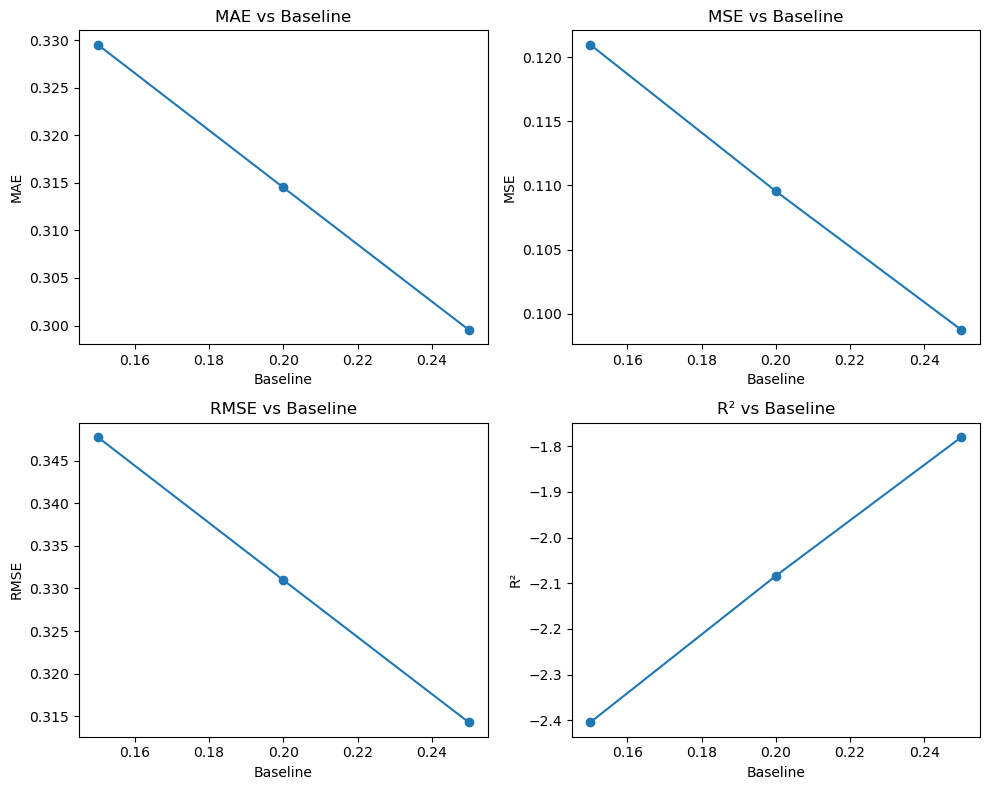

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Sensitivity analysis results
data = {
    "Baseline": [0.15, 0.20, 0.25],
    "MAE": [0.329540, 0.314518, 0.299537],
    "MSE": [0.120966, 0.109553, 0.098752],
    "RMSE": [0.347801, 0.330988, 0.314248],
    "R²": [-2.405048, -2.083797, -1.779748]
}

df_sens = pd.DataFrame(data)

# Plot sensitivity analysis
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# MAE
axes[0, 0].plot(df_sens["Baseline"], df_sens["MAE"], marker="o")
axes[0, 0].set_title("MAE vs Baseline")
axes[0, 0].set_xlabel("Baseline")
axes[0, 0].set_ylabel("MAE")

# MSE
axes[0, 1].plot(df_sens["Baseline"], df_sens["MSE"], marker="o")
axes[0, 1].set_title("MSE vs Baseline")
axes[0, 1].set_xlabel("Baseline")
axes[0, 1].set_ylabel("MSE")

# RMSE
axes[1, 0].plot(df_sens["Baseline"], df_sens["RMSE"], marker="o")
axes[1, 0].set_title("RMSE vs Baseline")
axes[1, 0].set_xlabel("Baseline")
axes[1, 0].set_ylabel("RMSE")

# R²
axes[1, 1].plot(df_sens["Baseline"], df_sens["R²"], marker="o")
axes[1, 1].set_title("R² vs Baseline")
axes[1, 1].set_xlabel("Baseline")
axes[1, 1].set_ylabel("R²")

plt.tight_layout()
plt.show()
